# Solar Power Forecasting Using Gaussian Processes (GP)

In this Notebook, we'll go through the general process of
1. loading and preparing our weather data for forecasting
2. training an approximate Gaussian Process and
3. evaluating its predictions
At the end, we'll have a basic understanding of how to do time-series forecasting with a Gaussian Process.

## Basic Imports and variable definitions

In [ ]:
! pip install gpytorch properscoring geopandas matplotlib contextily

import os
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/My Drive/ML for RES'
os.chdir(project_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import torch, gpytorch, os, time, pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import properscoring as ps
import math
from tqdm.notebook import tqdm
from gpytorch.likelihoods import MultitaskGaussianLikelihood
import os



from data_utils import load_and_merge_weather_data, load_supply_data, load_installed_cap_data, get_time_intersection, concat_tables, add_hour_column, add_year_column, df_to_tensor, save_data
from model_utils import get_cov_kernel, get_mean_kernel, load_model, load_file, perform_gridsearch, save_training_results
from plot_utils import plot_weather_correlation, plot_solar_supply_day, plot_solar_supply_whole, plot_installed_capacity, plot_time_columns, plot_geographical_clusters, plot_forecast_sanity_check

In [ ]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
torch.autograd.set_detect_anomaly(True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_cpu = torch.device('cpu') # For moving data back to cpu to make testing easier
print(f'using device: {device}')


RANDOM_SEED = 42

# How many hours we want to predict into the future
horizon = 24

data_folder = 'data'
weather_data_fpaths = [os.path.join(data_folder, weather_file)for weather_file in ['Weather_Data_Germany.csv', 'Weather_Data_Germany_2022.csv']]
supply_data_fpath = os.path.join(data_folder, 'Realised_Supply_Germany.csv')
cap_data_fpath = os.path.join(data_folder, 'Installed_Capacity_Germany.csv')
model_folder = 'models'

using device: cuda


# Loading the Data and combining the different tables
In total, three tables are loaded and combined in the scope of this project.
- Weather data: Contains hourly measurements of weather variables, such as sunshine duration (sund), recorded at multiple geographic locations with associated coordinates. For this project, spatial averaging is applied across all measurement stations. To evaluate the effect of spatial granularity, an additional experiment uses region-specific weather data by dividing the locations into four areas: Northwest, Northeast, Southeast, and Southwest, instead of averaging across all locations.
- Realised Supply: Contains 15-minute interval measurements of energy supply from various production sources, such as solar and hydro power. The actual solar energy supply is included and serves as the target variable for forecasting. For each target hour, the corresponding four 15-minute values can either be averaged or summed. By default, averaging is used, though this choice can be modified later in the notebook.
- Installed Capacity:  Includes annual records of total installed energy generation capacity, differentiated by energy source. For this project, only the solar capacity data is retained; all other energy sources are excluded from the analysis.

## Weather data
There is one table containing data between 2019-2022 and one with data from 2022. I combine both into one table for easier preprocessing.
Weather data is comprised of the following variables:


| Variable Short | Variable Long Name                                      |
|----------------|----------------------------------------------------------|
| z              | Geopotential                                             |
| cdir           | Clear-sky direct solar radiation at surface             |
| msl            | Mean sea level pressure                                 |
| tcc            | Total cloud cover                                       |
| u10            | U-component of wind at 10m                              |
| v10            | V-component of wind at 10m                              |
| u100           | U-component of wind at 100m                             |
| v100           | V-component of wind at 100m                             |
| t2m            | Temperature 2m above ground                             |
| ssr            | Surface net solar radiation                             |
| tsr            | Top net solar radiation                                 |
| sund           | Sunshine duration                                       |
| fsr            | Forecast surface roughness                              |
| tp             | Total precipitation                                     |
| blh            | Boundary layer height                                   |


The dataset contains hourly measurements from 80 locations across Germany and its surrounding regions. For each hour, the corresponding data points are averaged over the spatial dimension (across locations).

In [ ]:
weather_df = load_and_merge_weather_data(weather_data_fpaths)

weather_df.iloc[[0, 1, 23, 24, 25, -2, -1]]

,time,cdir,z,msl,blh,tcc,u10,v10,t2m,ssr,tsr,sund,tp,fsr,u100,v100
0,2019-01-01 00:00:00+00:00,0.000,3360.296561,103009.967750,507.635043,0.966562,3.867164,1.065368,278.216013,0.000000e+00,0.000,0.000000,0.000000e+00,0.741971,6.545994,1.122055
1,2019-01-01 01:00:00+00:00,0.000,3360.296561,102964.489612,544.627164,0.959348,4.092345,1.116217,278.310794,0.000000e+00,0.000,0.000000,3.803349e-05,0.742205,6.838839,1.241379
23,2019-01-01 23:00:00+00:00,3066853.275,3360.296561,102310.656087,1282.185074,0.628171,5.543300,-4.233978,276.084614,1.617137e+06,3531474.625,9901.251962,1.907228e-03,0.742104,8.717265,-6.877415
24,2019-01-02 00:00:00+00:00,0.000,3360.296561,102431.760900,1190.333533,0.660718,5.078227,-4.134211,275.615555,0.000000e+00,0.000,-0.007812,7.450581e-09,0.741824,8.010838,-6.809227
25,2019-01-02 01:00:00+00:00,0.000,3360.296561,102462.246775,1234.541036,0.598510,4.837781,-4.484831,275.565373,0.000000e+00,0.000,-0.007812,1.602382e-04,0.742285,7.592956,-7.328369
35062,2022-12-31 22:00:00+00:00,3010416.425,3360.300465,101413.335688,855.964935,0.824257,4.053605,4.901148,284.452551,2.210629e+06,4074921.825,11443.273025,5.087158e-03,0.745430,7.320207,8.137603
35063,2022-12-31 23:00:00+00:00,3010416.425,3360.300465,101444.050062,844.058690,0.809066,4.008353,4.860213,284.285022,2.210669e+06,4074921.825,11443.273025,5.100906e-03,0.745408,7.251386,8.022535


Also check the correlation between weather features - this will be used to remove features in the bonus task (feature selection).

Notably, strong correlations are observed among cdir, ssr, tsr, and sund, indicating a possible redundancy in solar-related features. Similarly, v10 and v100 as well as u10 and u100 show high correlation, reflecting the similarity between wind measurements at different altitudes.

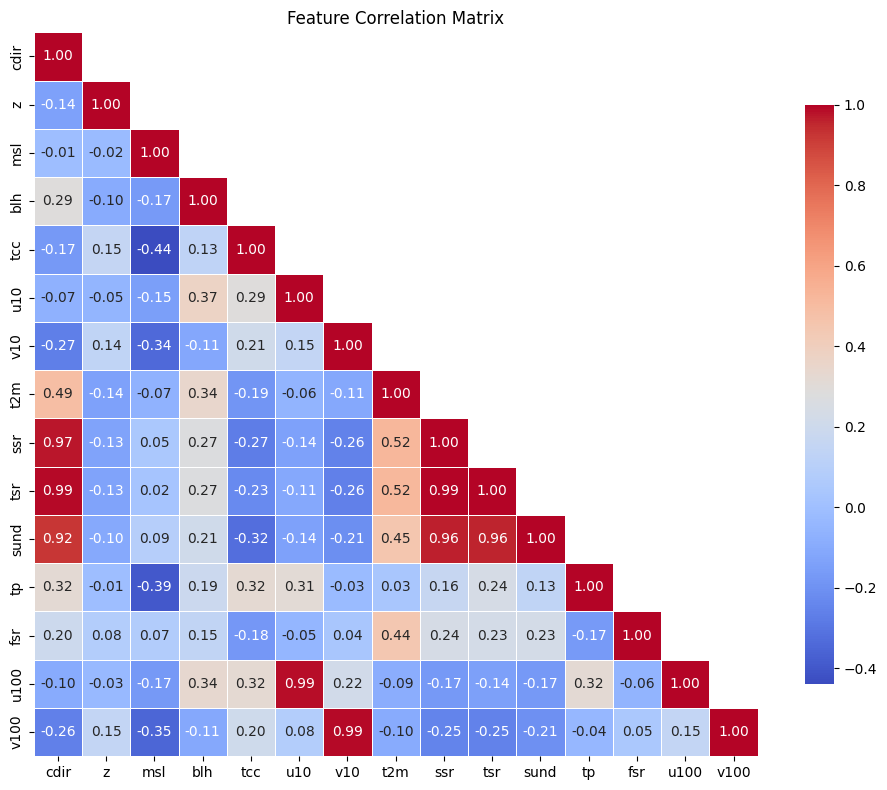

In [ ]:
plot_weather_correlation(weather_df)

## Solar Supply Data

This is the table that contains the solar energy supply, which is the target variable that are to be predicted.

It contains 15-minute interval measurements of energy supply from various production sources, such as solar and hydro power.

For each target hour, the corresponding four 15-minute values can either be averaged or summed. By default, the  average solar supply is used, though this can be modified later in the notebook.

In [ ]:
supply_hourly = load_supply_data(supply_data_fpath)
supply_hourly.head()

,time,solar_supply_sum,solar_supply_mean
0,2019-01-01 00:00:00+00:00,0.0,0.0
1,2019-01-01 01:00:00+00:00,0.0,0.0
2,2019-01-01 02:00:00+00:00,0.0,0.0
3,2019-01-01 03:00:00+00:00,0.0,0.0
4,2019-01-01 04:00:00+00:00,0.0,0.0


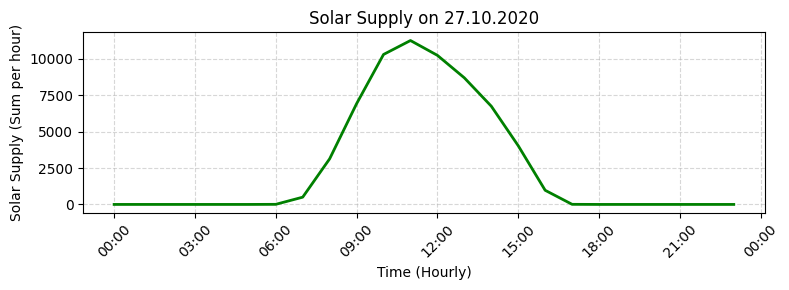

In [ ]:
random_date = np.random.choice(supply_hourly['time'].dt.date)
plot_solar_supply_day(random_date, supply_hourly)

we can see that the solar supply generally follows a (somewhat) Gaussian curve. So we'll try to use a Gaussian Likelihood function in our GP to predict the solar supply values.

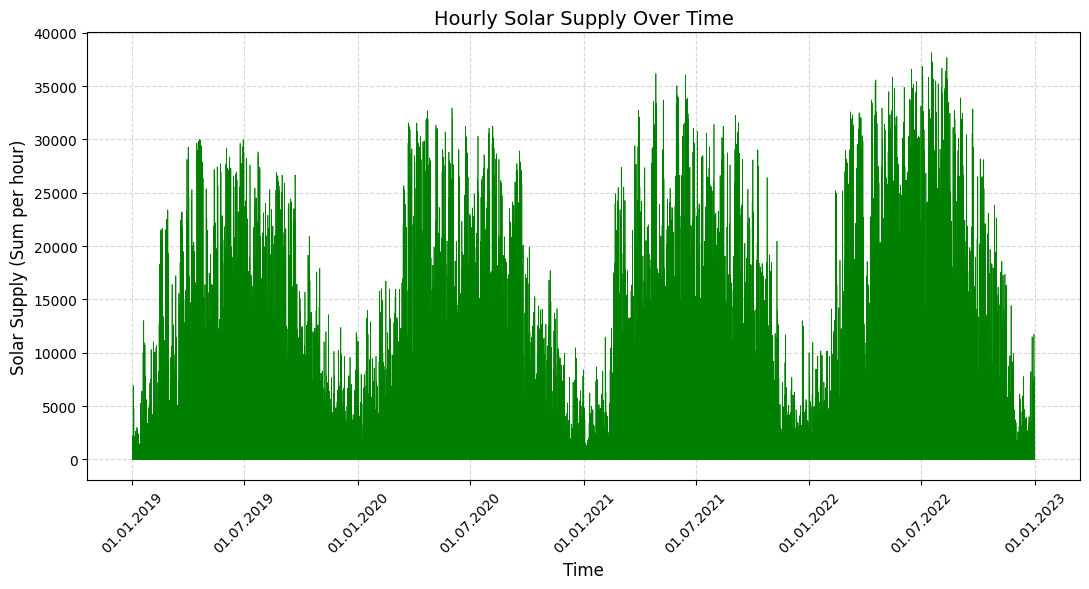

In [ ]:
plot_solar_supply_whole(supply_hourly)

We can see seasonal patterns quite well, and that the solar supply increases over the years. This is (at least partly) due to Germany investing and building lots of new solar farms, households being forced to install them on roofs after renovations and general efficiency improvements due to innovations.

## Installed solar capacity
This table contains the total capacity that's installed in Germany - The only problem is that it doesn't contain data for the 2018, which means that the starting point for the installed capacity in 2019 is missing. The missing data is filled with a constant value.

2019-01-01 00:00:00+00:00    44036.0
2023-01-01 00:00:00+00:00    57744.0
Freq: 35064h, Name: Photovoltaic [MW], dtype: float64


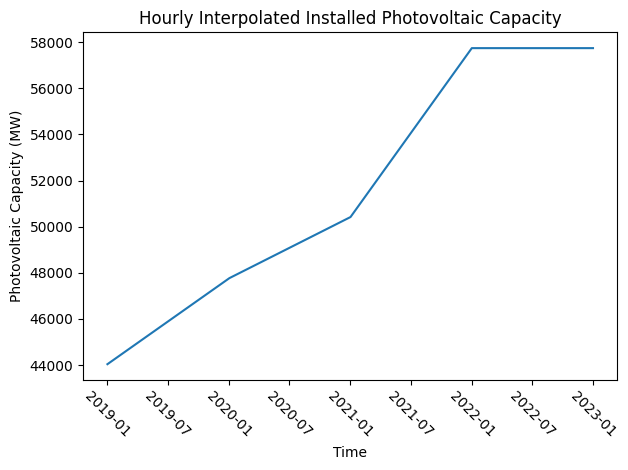

In [ ]:
capacity_df = load_installed_cap_data(cap_data_fpath)

print(capacity_df.iloc[[0, -1]])
plot_installed_capacity(capacity_df)

## Combine the tree tables based on the intersection of dates present

- Only use the data points from dates which are included in all datasets
- Here we can also decide whether to predict the mean or the sum for each hour of our solar supply data.

In [ ]:
print(f"Supply data ranges from {supply_hourly['time'].min()} to {supply_hourly['time'].max()}")
print(f"Weather data ranges from {weather_df['time'].min()} to {weather_df['time'].max()}")
print(f"Installed capacity ranges from {capacity_df.index.min()} to {capacity_df.index.max()}")
common_time_idx = get_time_intersection(weather_df, supply_hourly, capacity_df)

Supply data ranges from 2019-01-01 00:00:00+00:00 to 2022-12-31 23:00:00+00:00
Weather data ranges from 2019-01-01 00:00:00+00:00 to 2022-12-31 23:00:00+00:00
Installed capacity ranges from 2019-01-01 00:00:00+00:00 to 2023-01-01 00:00:00+00:00
Common window: 2019-01-01 00:00:00+00:00 - 2022-12-31 23:00:00+00:00


In [ ]:
target_col = 'solar_supply_mean'  # or 'solar_supply_sum'
full_data = concat_tables(common_time_idx, supply_hourly, weather_df, capacity_df, target_col)

## Add time encoding
For encoding time, sinusoidal encodings that represent the time of day and the day of a year are added. For this, four columns are added. Two columns that contain the Sine and Cosine functions with a period of 24 hours and two that have a period of 365 days (or 366 in case of a leap year)

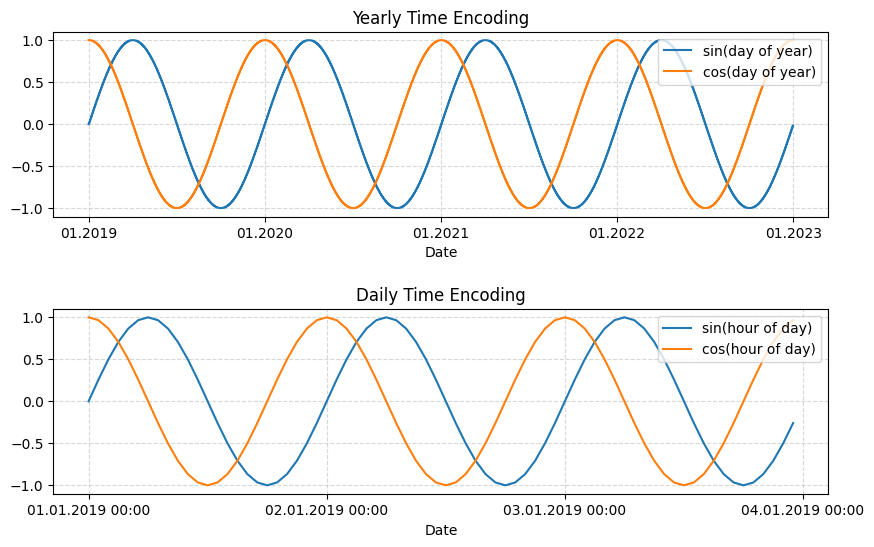

In [ ]:
add_hour_column(full_data)
add_year_column(full_data)

plot_time_columns(full_data)

The resulting dataset contains the weather variables, installed capacity, solar supply and 4 columns that represent the day within a year as well as the hour of within a day.

In [ ]:
full_data

,solar_supply,cdir,z,msl,blh,tcc,u10,v10,t2m,ssr,...,sund,tp,fsr,u100,v100,Installed_Capacity,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
2019-01-01 00:00:00+00:00,0.0,0.000,3360.296561,103009.967750,507.635043,0.966562,3.867164,1.065368,278.216013,0.000000e+00,...,0.000000,0.000000,0.741971,6.545994,1.122055,44036.000000,0.000000,1.000000,0.000000,1.000000
2019-01-01 01:00:00+00:00,0.0,0.000,3360.296561,102964.489612,544.627164,0.959348,4.092345,1.116217,278.310794,0.000000e+00,...,0.000000,0.000038,0.742205,6.838839,1.241379,44036.424429,0.258819,0.965926,0.000000,1.000000
2019-01-01 02:00:00+00:00,0.0,0.000,3360.296561,102908.208325,575.103757,0.966846,4.320050,1.223478,278.206292,0.000000e+00,...,0.000000,0.000070,0.742254,7.183921,1.428783,44036.848858,0.500000,0.866025,0.000000,1.000000
2019-01-01 03:00:00+00:00,0.0,0.000,3360.296561,102827.034387,612.314609,0.979125,4.638074,1.222571,278.140331,0.000000e+00,...,0.000000,0.000099,0.742272,7.660834,1.501984,44037.273288,0.707107,0.707107,0.000000,1.000000
2019-01-01 04:00:00+00:00,0.0,0.000,3360.296561,102725.913987,660.112603,0.981526,4.980449,1.055763,278.102989,0.000000e+00,...,0.000000,0.000135,0.742255,8.147790,1.289936,44037.697717,0.866025,0.500000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00+00:00,0.0,3010497.350,3360.300465,101343.109762,772.449598,0.894857,3.526524,4.758480,284.654883,2.210629e+06,...,11443.273025,0.004806,0.745599,6.526197,7.935821,57744.000000,-0.965926,0.258819,-0.017213,0.999852
2022-12-31 20:00:00+00:00,0.0,3010497.350,3360.300465,101364.929637,835.039963,0.864447,3.794407,4.867906,284.625625,2.210629e+06,...,11443.273025,0.004993,0.745539,6.902650,8.148097,57744.000000,-0.866025,0.500000,-0.017213,0.999852
2022-12-31 21:00:00+00:00,0.0,3010416.425,3360.300465,101389.839013,853.389589,0.841012,3.948474,4.908642,284.563871,2.210629e+06,...,11443.273025,0.005059,0.745457,7.133971,8.186220,57744.000000,-0.707107,0.707107,-0.017213,0.999852
2022-12-31 22:00:00+00:00,0.0,3010416.425,3360.300465,101413.335688,855.964935,0.824257,4.053605,4.901148,284.452551,2.210629e+06,...,11443.273025,0.005087,0.745430,7.320207,8.137603,57744.000000,-0.500000,0.866025,-0.017213,0.999852


# Preprocessing data and creating the train and test datasets

This step involves standadization of each input feature to have a mean $\mu=0$ and a standard deviation $\sigma=1$ based on the train data. It also involves creating the forecast ground truths based on the forecast-horizon (i.e. 24 hours) and splitting the data into train/test set.

Each column of the data needs to be standardized **individually**! The sine and cosine encodings of time are **not standardized**, as sine/cosine are already bounded normalized  to the range $[-1, 1]$ and standardizing these would distort their geometric structure on the unit circle, breaking the periodic information they're intended to preserve.

$$\operatorname{Standardization: } z=\frac{x-\mu}{\sigma}$$

**Additionally**, the solar generation values from 6, 12, 18 and 24 hours ago are included in the input data for each point in time.

In [ ]:
def create_forecast_df(data, horizon):
    df = pd.concat(
        {f'y+{i}h':
        data[target_col].shift(-i) for i in range(1, horizon+1)},
        axis=1
    ).dropna() # dropna removes the last #horizon instances as they contain NaNs
    return df

def create_standardized_data(data, static_features, target_feature, train_idx, y_index, target_scaler, lags=[6, 12, 18, 24]):
    # Fit a StandardScaler to the columns (except for the target feature and static features)
    features = data.columns.tolist()
    features_to_scale = [c for c in features if (c not in static_features and c != target_feature)]
    feature_scaler = StandardScaler().fit(data.loc[train_idx, features_to_scale])

    # Apply feature scaler to the reduced full data
    # Scale the continuous features and leave time features untouched
    data_scaled = data.copy()
    data_scaled.loc[:, features_to_scale] = feature_scaler.transform(data_scaled[features_to_scale])
    data_scaled[target_feature] = target_scaler.transform(data_scaled[[target_feature]])

    # Create lagged features (t-i for i in lags). This includes solar supplies from previous time points, e.g. 6, 12, 18 and 24 hours ago.
    for lag in lags:
      lagged_col_name = f"{target_feature}_t-{lag}"
      data_scaled[lagged_col_name] = data_scaled[target_feature].shift(lag)
    if len(lags)>0:
      # Drop rows with NaNs introduced by lagging
      data_scaled.dropna(subset=[f"{target_feature}_t-{lag}" for lag in lags], inplace=True)
    # This removes the first entries, so we need to adapt the y_index (where the last 24 values are removed)
    #   Adjust y_index to only include indices that still exist in data_scaled
    adjusted_y_index = y_index.intersection(data_scaled.index)

    # Ensure only values from the full table are taken for which there are values in the y_df (where the last 24 entries are removed)
    X_df = data_scaled.loc[adjusted_y_index]

    # Split into train and test
    train_mask = X_df.index.year < last_year

    # Extract train and test data
    X_train_scaled, X_test_scaled = X_df.loc[train_mask], X_df.loc[~train_mask]

    return data_scaled, X_train_scaled, X_test_scaled, feature_scaler, train_mask, adjusted_y_index

Train a StandardScaler that can standardize our Solar Supply column

In [ ]:
# test_idx are all datapoints corresponding to the last year
last_year = full_data.index.year.max()
train_idx = full_data.index.year < last_year

# Identify which columns to scale vs. which ones to keep. -> Keep the time (sin & cos) columns
target_col   = 'solar_supply'
feature_cols_static = ['hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos'] # these go straight into X without scaling

# Train feature scalers that standardize the columns
# target_scaler trained on all solar_supply column from the train dataset
target_scaler = StandardScaler().fit(full_data.loc[train_idx, [target_col]])

In [ ]:
# Standardize input data
y_index = create_forecast_df(full_data, horizon).index
full_data_std, X_train, X_test, feature_scaler, train_mask, y_index = create_standardized_data(full_data, feature_cols_static, target_col, train_idx, y_index, target_scaler)

# Create Forecast DF and ground truth data y
y_df = create_forecast_df(full_data_std, horizon)
y_train, y_test = y_df.loc[train_mask], y_df.loc[~train_mask]

# Extract train and test dates for plotting purposes
dates_train = full_data_std.loc[y_index].loc[train_mask].index
dates_test = full_data_std.loc[y_index].loc[~train_mask].index

# Shapes check
print(f'Train data | X: {X_train.shape} y: {y_train.shape}')  # (n_train, n_features), (n_train, 24)
print(f'Test data  | X: {X_test.shape} y: {y_test.shape}')   # (n_test,  n_features), (n_test,  24)

Train data | X: (26280, 25) y: (26280, 24)
Test data  | X: (8736, 25) y: (8736, 24)


Look at the resulting datasets

In [ ]:
full_data_std.head()

,solar_supply,cdir,z,msl,blh,tcc,u10,v10,t2m,ssr,...,v100,Installed_Capacity,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,solar_supply_t-6,solar_supply_t-12,solar_supply_t-18,solar_supply_t-24
2019-01-02 00:00:00+00:00,-0.653639,-0.901071,9.094947e-13,0.900634,1.615182,0.060135,1.837466,-2.460230,-1.025674,-0.859166,...,-2.453210,-1.540027,0.000000,1.000000,0.017213,0.999852,-0.653639,-0.368019,-0.653639,-0.653639
2019-01-02 01:00:00+00:00,-0.653639,-0.901071,9.094947e-13,0.934180,1.727770,-0.214316,1.727689,-2.642626,-1.032728,-0.859166,...,-2.616943,-1.539911,0.258819,0.965926,0.017213,0.999852,-0.653639,-0.396846,-0.653639,-0.653639
2019-01-02 02:00:00+00:00,-0.653639,-0.901071,9.094947e-13,0.999948,1.717112,-0.262669,1.610993,-2.801550,-1.055196,-0.859166,...,-2.761044,-1.539795,0.500000,0.866025,0.017213,0.999852,-0.653639,-0.487617,-0.642857,-0.653639
2019-01-02 03:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.040758,1.754450,-0.328661,1.543875,-2.953307,-1.081040,-0.859166,...,-2.911166,-1.539679,0.707107,0.707107,0.017213,0.999852,-0.653639,-0.596688,-0.579059,-0.653639
2019-01-02 04:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.083646,1.817195,-0.390214,1.381965,-3.048589,-1.109085,-0.859166,...,-3.009084,-1.539563,0.866025,0.500000,0.017213,0.999852,-0.653639,-0.650856,-0.478466,-0.653639


In [ ]:
y_df.head()

,y+1h,y+2h,y+3h,y+4h,y+5h,y+6h,y+7h,y+8h,y+9h,y+10h,...,y+15h,y+16h,y+17h,y+18h,y+19h,y+20h,y+21h,y+22h,y+23h,y+24h
2019-01-02 00:00:00+00:00,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.639786,-0.464260,-0.122744,...,-0.461669,-0.643017,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639
2019-01-02 01:00:00+00:00,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.639786,-0.464260,-0.122744,0.157054,...,-0.643017,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639
2019-01-02 02:00:00+00:00,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.639786,-0.464260,-0.122744,0.157054,0.233170,...,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639
2019-01-02 03:00:00+00:00,-0.653639,-0.653639,-0.653639,-0.653639,-0.639786,-0.464260,-0.122744,0.157054,0.233170,0.148895,...,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639
2019-01-02 04:00:00+00:00,-0.653639,-0.653639,-0.653639,-0.639786,-0.464260,-0.122744,0.157054,0.233170,0.148895,-0.107994,...,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639,-0.653639


Now the DataFrames need to be converted to tensors to be able to serve as inputs to the model

In [ ]:
# Convert data to tensors
X_train, y_train, X_test, y_test = map(
    lambda x: df_to_tensor(x, device), (X_train, y_train, X_test, y_test)
)

Save them for re-use

In [ ]:
save_data(X_train, X_test, y_train, y_test, dates_train, dates_test, os.path.join(data_folder, "data.pt"))

Datasets saved successfully


Sanity check: Check whether y_train contains the next 24 hours solar supply from X_train

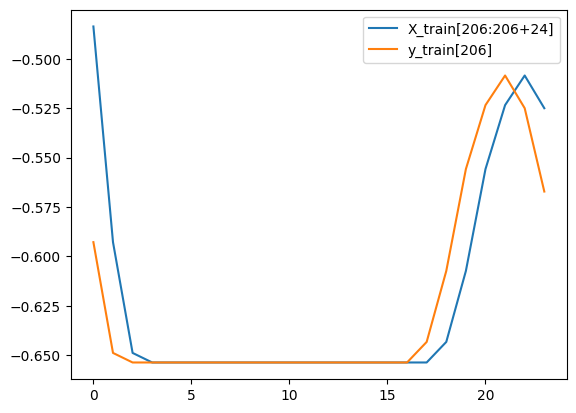

In [ ]:
plot_forecast_sanity_check(206, X_train, y_train, horizon)

# Model & training

## Model: Approximate Variational Multi-Output Gaussian Process

This notebook employs an advanced machine learning technique called a Variational Gaussian Process (GP) model with a Latent Multi-Output (LMC) structure to predict hourly solar power generation up to 24 hours into the future.

Here's why I chose this model and how it works:

#### 1. What is a Gaussian Process (GP)?
- A Gaussian Process is a powerful non-linear regression model that provides a point prediction and an uncertainty estimate (predictive variance) around that prediction for each input.
- It assumes that the outputs for nearby inputs are correlated, and it learns this correlation structure from the data using a "kernel" function.
- The GP predicts a distribution over functions.

##### **Mathematical definition:**
A Gaussian Process defines a distribution over functions, where the values of the function at any finite set of inputs are jointly Gaussian distributed. <br>
A GP is fully specified by a mean function $\mu(\mathbf{x})$ and a covariance (kernel) function $k(\mathbf{x}, \mathbf{x}')$

$$f(\mathbf{x}) \sim \mathcal{G P}\left(\mu(\mathbf{x}), k\left(\mathbf{x}, \mathbf{x}^{\prime}\right)\right)$$

  - $\mu(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})]$ defines the expected value of the function.
  - $k(\mathbf{x}, \mathbf{x}') = \text{Cov}(f(\mathbf{x}), f(\mathbf{x}'))$ defines how correlated outputs are at different input locations.

Given $N$ training inputs $\mathbf{X} = [\mathbf{x}_1, ..., \mathbf{x}_N]$ and targets $\mathbf{y}$, the GP prior implies that:
$$\mathbf{f} \sim \mathcal{N}(\mu, \mathbf{K}) \quad \text{where} \quad \mu_i=\mu\left(\mathbf{x}_i\right), \quad K_{i j}=k\left(\mathbf{x}_i, \mathbf{x}_j\right)$$

Once we observe training data $\mathcal{D} = {\mathbf{X}, \mathbf{y}}$, we condition the GP prior on these observations, which gives us a posterior distribution over functions. This posterior tells us which functions are now plausible given the observed data — assigning high probability to those that fit the data well and low probability to those that don’t. For a new input $\mathbf{x}_*$, this results in a predictive distribution:
$f(x_*) \mid D \sim N(μ_*,σ_*^2)$

where $\mu_*$ is the predicted mean (the most likely value of the function) and $\sigma_*^2$ is the predictive variance (quantifying uncertainty at that input). <br>
This is how GPs deliver both point predictions and also uncertainty estimates: the model doesn't just output a value. It outputs a full Gaussian distribution for each new input.



#### 2. Why an Approximate Variational GP?
- Standard (exact) GPs are powerful but also computationally very expensive wich a computational cost of $\mathcal{O}(N^3)$ where $N$ is the number of data points. This is not practical with our ~26,000 data points.
- To overcome this, I use an approximate GP model. This approach uses a technique called variational inference and introduces a smaller set of "inducing points" ($M=2048$ in this case). <br>
By using inducing points and variational inference, the computational complexity is significantly reduced to approximately $\mathcal{O}(NM^2)$, making the model scalable to our dataset.
  - Inducing-Point Initialization: We sample 2048 points uniformly from our inputs and set `learn_inducing_locations=True` so their positions adapt during training to cover the data optimally.
- The training process involves **maximizing the Evidence Lower Bound (ELBO)**, which is a proxy objective that allows us to efficiently optimize the model and approximate the true underlying relationships in the data.
- What is Variational Inference?
  - In GPs, we are often interested in the "posterior distribution" which tells us the probability of different latent functions given the observed data. Calculating this true posterior exactly is usually intractable.
  - Variational inference is a technique to approximate this true posterior distribution with a simpler, more manageable distribution (called the "variational distribution"). We choose a variational distribution that is easy to work with and has parameters that we can optimize.
  - The goal of variational inference is to find the parameters of the variational distribution that make it as "close" as possible to the true posterior.
- Maximizing the ELBO: The ELBO is a theoretical lower bound on the marginal likelihood of the data given the model parameters.
  - The marginal likelihood represents how well the model explains the observed data, essentially integrating over all possitble latent functions. We would ideally want to maximize the marginal likelihood to find the best model parameters.
  - Maximizing the marginal likelihood is usually intractable, so we maximize the ELBO as a proxy.
  - Maximizing the ELBO is equivalent to minimizing the Kullback-Leibler divergence between the true posterior distribution (ground-truth) and our variational distribution (our approximation).
  - Therefore, by maximizing the ELBO, we are simultaneously making our variational approximation better and finding better model parameters.

#### 3. Why a Multi-Output (LMC) Structure?
- The task doesn't just include predicting one future hour, but 24 future hours simultaneously. These future hourly predictions are likely to be related (e.g., if solar generation is high in the next hour, it's likely to be high in the hour after that too).
- **Latent Multi-Output Covatiance (LMC)** is a method for multi-output GPs. It models multiple related outputs as linear combinations of a smaller number of independent "latent" GPs. This allows the model to learn and capture dependencies and correlations between the different forecast horizons, leading to more coherent and potentially more accurate multi-step predictions.
- I pair the GP prior with a `MultitaskGaussianLikelihood`, which learns a separate noise variance for each of the 24 output hours. This lets the model jointly learn signal covariance with the kernel and the observation noise for each hour, yielding better uncertainty estimates.

#### 4. Kernel & Mean Details
- **Mean Module:** `ConstantMean` (one learned bias per latent GP) lets each latent function float around its own learned baseline.  
- **Covariance Module:** an `RBFKernel` inside a `ScaleKernel`, batched over `num_latents`.  
  - The RBF kernel enforces smoothness (infinitely differentiable processes), appropriate for smoothly varying solar power generation.  
  - `ScaleKernel` learns an overall variance per latent GP.

In essence, this model provides a robust and scalable way to forecast future solar power generation, offering valuable uncertainty estimates by approximating a powerful GP model and specifically handling the correlations between the different forecast horizons using an LMC structure.

In [ ]:
class GPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points, num_tasks, num_latents,
                 mean_module, covar_module):
        """
        inducing_points: Tensor (M, D)
        num_tasks:       # of outputs, here 24
        num_latents:     # of latent GPs to mix (<= num_tasks)
        mean_module:     a gpytorch.means.Mean object, batched [num_latents]
        covar_module:    a gpytorch.kernels.Kernel within ScaleKernel, batched
        """
        # 1) variational distribution for each latent GP
        M = inducing_points.size(0)
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            M, batch_shape=torch.Size([num_latents])
        )
        # 2) single‐task variational strategy, batched
        base_vs = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points.unsqueeze(0).expand(num_latents, M, -1),
            variational_distribution,
            learn_inducing_locations=True
        )
        # 3) mix latents → tasks
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            base_vs, num_tasks, num_latents, latent_dim=-1
        )
        super().__init__(variational_strategy)

        # plug in chosen mean & covar modules
        self.mean_module = mean_module
        self.covar_module = covar_module

    def forward(self, x):
        # x: (..., D)
        mean = self.mean_module(x) # (num_latents, N)
        covar = self.covar_module(x) # (num_latents, N, N)
        return gpytorch.distributions.MultivariateNormal(mean, covar)

## Parameter Search to find the model hyperparameters that fit the data best

Define the search space for our grid-search: Number of inducing points, latent dimension, learning rates, epochs, mean kernels and covariance kernels

In [ ]:
inducing_list = [512, 1024]
latents_list  = [4, 8, 12]
lr_list       = [1e-3, 5e-3, 1e-2]
epochs_list   = [250, 350, 500, 750]
mean_options = ['Constant', 'Zero', 'Linear']
cov_options = ['RBF', 'Matern32_nu_2_5', 'Matern32_nu_2_5+Periodic', 'RBFxPeriodic', 'RBFxPeriodic+Matern_nu_2_5']

best_config = perform_gridsearch(cov_options, mean_options, inducing_list, latents_list, epochs_list, lr_list, device, RANDOM_SEED, X_train, y_train, GPModel)

print('Best configuration:')
for k,v in best_config.items():
    print(f'  {k:12s} : {v}')

with open(os.path.join(model_folder, "best_config.pkl"), "wb") as f:
    pickle.dump(best_config, f)

## Train the model with the parameters found during gridsearch

Training is done with a the Adam optimizer, a learning rate of $10^{-3}$ for 400 epochs. There are 12 latent GPs that are linearly combined to produce one prediction. Each GP has 1024 inducing points with a constant mean kernel and the RBF covariance kernel.

In [ ]:
best_config = load_file(os.path.join(model_folder, "best_config.pkl"))

for k,v in best_config.items():
    print(f'  {k:12s} : {v}')

  cov_kernel   : RBF
  mean_kernel  : Constant
  num_inducing : 1024
  num_latents  : 12
  lr           : 0.001
  epochs       : 400


In [ ]:
def create_model(best_config, inducing_points, input_size, horizon=24, device="cpu"):
    # Extract necessary parameters from best_config
    num_inducing = best_config['num_inducing']
    num_latents = best_config['num_latents'] # Compression dimension, max = horizon (24 values in this case)
    mean_kernel = get_mean_kernel(name=best_config.get('mean_kernel'), input_size=input_size)(num_latents)
    cov_kernel = get_cov_kernel(name=best_config.get('cov_kernel'))(num_latents)
    # Create the Approximate Gaussian Process model and Gaussian likelihood
    model = GPModel(inducing_points=inducing_points,
                    num_tasks=horizon, # Falls fehler aufkommt. Model war vorher num_tasks=y_train.shape[1]
                    num_latents=num_latents,
                    mean_module=mean_kernel, covar_module=cov_kernel).to(device)
    likelihood = MultitaskGaussianLikelihood(num_tasks=horizon).to(device)
    return model, likelihood

def train_model(model, likelihood, best_config, data, device="cpu", test_interval=25):
    # Split data into Train and Test
    _X_train, _y_train, _X_test, _y_test = data
    num_train_samples = _X_train.size(0)
    num_test_samples = _X_test.size(0)

    # Extract relevant parameters from best_config
    num_epochs = best_config['epochs']
    learning_rate = best_config['lr']

    model.train()
    likelihood.train()

    # Variational ELBO
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=_X_train.size(0))

    optimizer = torch.optim.Adam(
        [{'params': model.parameters()}, {'params': likelihood.parameters()}],
        lr = learning_rate
    )

    # Create a dataloader to enable training and testing in mini-batches
    train_ds = torch.utils.data.TensorDataset(_X_train, _y_train)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=2048, shuffle=True)
    test_ds = torch.utils.data.TensorDataset(_X_test, _y_test)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=2048, shuffle=False)


    # Track train and test losses
    train_losses = []
    test_losses = []

    # Training loop
    with tqdm(total=num_epochs, desc="Training Model") as pbar:
        for epoch in range(num_epochs):
            # Train step
            epoch_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                output = model(X_batch)
                loss = -mll(output, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.5)
                optimizer.step()

                # Track epoch loss weighted by batch size to calculate per-sample loss
                epoch_loss += loss.item() * X_batch.size(0)

            train_loss_per_sample = epoch_loss / num_train_samples if num_train_samples > 0 else 0
            train_losses.append(train_loss_per_sample)

            # Test step
            test_loss = None
            if epoch % test_interval == 0 or epoch == num_epochs - 1:
                epoch_test_loss = 0

                # Set to evaluation mode
                model.eval()
                likelihood.eval()

                with torch.no_grad(), gpytorch.settings.fast_pred_var():
                    for X_batch_test, y_batch_test in test_loader:
                        X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)
                        test_output = model(X_batch_test)
                        batch_test_loss = -mll(test_output, y_batch_test).item()
                        epoch_test_loss += batch_test_loss * X_batch_test.size(0)
                    test_loss_per_sample = epoch_test_loss / num_test_samples if num_test_samples > 0 else 0
                    test_losses.append(test_loss_per_sample)

                # Set to train mode
                model.train()
                likelihood.train()

            # Update progress bar
            update_dict = {'train_loss': f'{train_loss_per_sample:.6f}'}
            if test_loss is not None:
                 update_dict['test_loss'] = f'{test_loss:.6f}'
            else: # display last calculated test loss between intervals
                update_dict['test_loss'] = f'{test_losses[-1]:.6f}'
            pbar.set_postfix(update_dict)
            pbar.update(1)

    model.eval()
    likelihood.eval()

    return model, likelihood, train_losses, test_losses

Train the model

In [ ]:
perm = torch.randperm(X_train.size(0))
num_inducing = best_config.get('num_inducing')
inducing_points = X_train[perm[:num_inducing]].clone()
model, likelihood = create_model(best_config, inducing_points=inducing_points, input_size=X_train.shape[1], device=device)
model, likelihood, train_losses, test_losses = train_model(model, likelihood, best_config, data=(X_train, y_train, X_test, y_test), device=device, test_interval=25)

save_training_results(model, likelihood, train_losses, test_losses)

Training Model:   0%|          | 0/400 [00:00<?, ?it/s]

Saved model and likelihood successfully.


Look at the train and test losses, which correspond to the Evidence Lower Bound (ELBO)

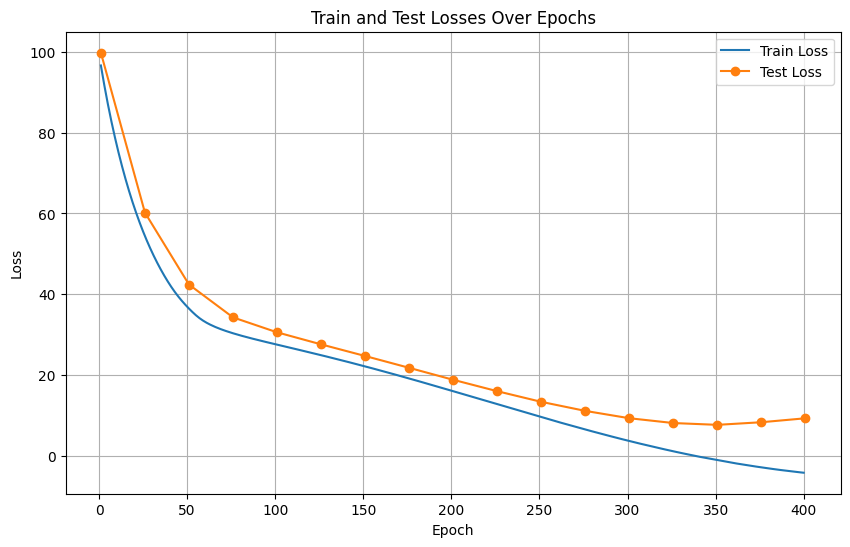

In [ ]:
def plot_losses(train_losses, test_losses, test_interval=25):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')

    # Create epochs for test losses based on the interval
    test_epochs = [i * test_interval + 1 for i in range(len(test_losses))]

    plt.plot(test_epochs, test_losses, label='Test Loss', marker='o')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train and Test Losses Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the losses
plot_losses(train_losses, test_losses)

# Bonus Task: Testing different feature selection approaches - Dataset preparation

#### Approach 1: Removing features based on correlation

When looking at the heat map from above, it's apparent that some features are highly correlated.

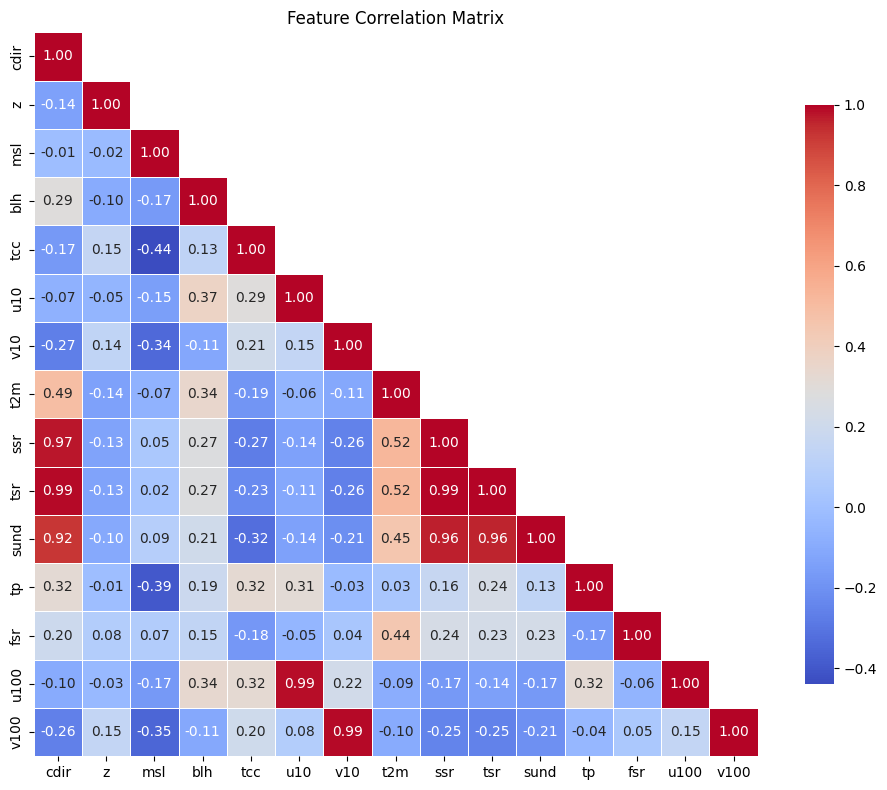

In [ ]:
plot_weather_correlation(weather_df)

Highly correlated features are:
- Group 1: cdir & ssr & tsr & sund
- Group 2: u10 & u100
- Group 3: v10 & v100

From each group of correlated features, only one feature is kept.
For Group 1, this is the Surface net solar radiation (*ssr*), for Group 2, this is the u-component of wind at 10m (*u10*) and for Group 3 the v-component of wind at 10m (*v10*)

In [ ]:
y_index_corr = create_forecast_df(full_data, horizon).index

# X_df contains the ready dataset. We need to remove columns that we don't want to keep
highly_correlated_cols = ['cdir', 'sund', 'tsr', 'u100', 'v100']
# Remove the highly correlated columns
full_data_corr = full_data.drop(columns=highly_correlated_cols)
full_data_std_corr, X_train_corr, X_test_corr, feature_scaler_corr, train_mask_corr, y_index_corr = create_standardized_data(full_data_corr, feature_cols_static, target_col, train_idx, y_index_corr, target_scaler)

# Create ground truth data y and map it to tensors
y_df_corr = create_forecast_df(full_data_std_corr, horizon)
y_train_corr, y_test_corr = y_df_corr.loc[train_mask_corr], y_df_corr.loc[~train_mask_corr]
X_train_corr, X_test_corr, y_train_corr, y_test_corr = map(lambda x: df_to_tensor(x, "cpu"), (X_train_corr, X_test_corr, y_train_corr, y_test_corr))

# Extract train and test dates for plotting purposes
dates_train_corr = full_data_std_corr.loc[y_index_corr].loc[train_mask_corr].index
dates_test_corr = full_data_std_corr.loc[y_index_corr].loc[~train_mask_corr].index

save_data(X_train_corr, X_test_corr, y_train_corr, y_test_corr, dates_train_corr, dates_test_corr, os.path.join(data_folder, "data_corr.pt"))

print(X_train_corr.shape, X_test_corr.shape, y_train_corr.shape, y_test_corr.shape)
full_data_std_corr.head()

Datasets saved successfully
torch.Size([26280, 20]) torch.Size([8736, 20]) torch.Size([26280, 24]) torch.Size([8736, 24])


,solar_supply,z,msl,blh,tcc,u10,v10,t2m,ssr,tp,fsr,Installed_Capacity,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,solar_supply_t-6,solar_supply_t-12,solar_supply_t-18,solar_supply_t-24
2019-01-02 00:00:00+00:00,-0.653639,9.094947e-13,0.900634,1.615182,0.060135,1.837466,-2.460230,-1.025674,-0.859166,-0.722262,-0.453868,-1.540027,0.000000,1.000000,0.017213,0.999852,-0.653639,-0.368019,-0.653639,-0.653639
2019-01-02 01:00:00+00:00,-0.653639,9.094947e-13,0.934180,1.727770,-0.214316,1.727689,-2.642626,-1.032728,-0.859166,-0.625252,-0.280314,-1.539911,0.258819,0.965926,0.017213,0.999852,-0.653639,-0.396846,-0.653639,-0.653639
2019-01-02 02:00:00+00:00,-0.653639,9.094947e-13,0.999948,1.717112,-0.262669,1.610993,-2.801550,-1.055196,-0.859166,-0.528590,-0.252569,-1.539795,0.500000,0.866025,0.017213,0.999852,-0.653639,-0.487617,-0.642857,-0.653639
2019-01-02 03:00:00+00:00,-0.653639,9.094947e-13,1.040758,1.754450,-0.328661,1.543875,-2.953307,-1.081040,-0.859166,-0.403418,-0.258196,-1.539679,0.707107,0.707107,0.017213,0.999852,-0.653639,-0.596688,-0.579059,-0.653639
2019-01-02 04:00:00+00:00,-0.653639,9.094947e-13,1.083646,1.817195,-0.390214,1.381965,-3.048589,-1.109085,-0.859166,-0.290733,-0.222203,-1.539563,0.866025,0.500000,0.017213,0.999852,-0.653639,-0.650856,-0.478466,-0.653639


As a result, we have 20 remaining features, compared to 25 before!

In [ ]:
# Move data to GPU (if available)
X_train_corr, X_test_corr, y_train_corr, y_test_corr = X_train_corr.to(device), X_test_corr.to(device), y_train_corr.to(device), y_test_corr.to(device)
# Train model
perm = torch.randperm(X_train_corr.size(0))
num_inducing = best_config.get('num_inducing')
inducing_points = X_train_corr[perm[:num_inducing]].clone()
model_corr, likelihood_corr = create_model(best_config, inducing_points=inducing_points, input_size=X_train_corr.shape[1], device=device)
model_corr, likelihood_corr, train_losses_corr, test_losses_corr = train_model(model_corr, likelihood_corr, best_config, data=(X_train_corr, y_train_corr, X_test_corr, y_test_corr), device=device, test_interval=25)
# Move back to CPU to free up space on the GPU
X_train_corr, X_test_corr, y_train_corr, y_test_corr = X_train_corr.to(device_cpu), X_test_corr.to(device_cpu), y_train_corr.to(device_cpu), y_test_corr.to(device_cpu)
# Save results
save_training_results(model_corr, likelihood_corr, train_losses_corr, test_losses_corr, name_addition='_corr')

Training Model:   0%|          | 0/400 [00:00<?, ?it/s]

Saved model and likelihood successfully.


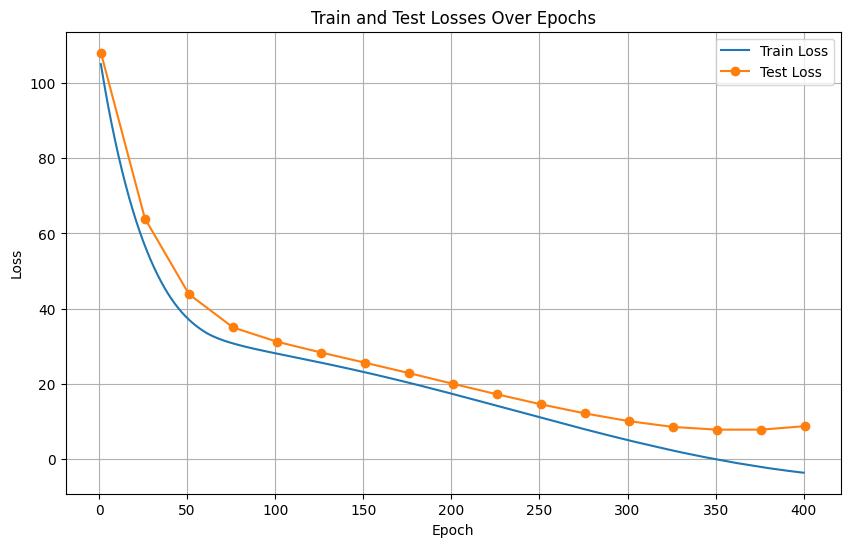

In [ ]:
plot_losses(train_losses_corr, test_losses_corr)

#### Approach 2: Remove the columns of data that correspond to previous solar generation values

The dataset contains the current and also past solar generation values from 6, 12, 18 and 24 hours ago. By removing the past values, it can be seen how beneficial including these are to the prediction quality and also how strongly the model relies on. There's the possibility that the model relies too strongly on past values, instead of the weather variables to make prediction - which could actually harm the predictive performance of the model.

In [ ]:
y_index_nolag = create_forecast_df(full_data, horizon).index
# Remove the installed capacity column
full_data_std_nolag, X_train_nolag, X_test_nolag, feature_scaler_nolag, train_mask_nolag, y_index_nolag = create_standardized_data(full_data, feature_cols_static, target_col, train_idx, y_index_nolag, target_scaler, lags=[])

# Create ground truth data y and map it to tensors
y_df_nolag = create_forecast_df(full_data_std_nolag, horizon)
y_train_nolag, y_test_nolag = y_df_nolag.loc[train_mask_nolag], y_df_nolag.loc[~train_mask_nolag]
X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag = map(lambda x: df_to_tensor(x, "cpu"), (X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag))

# Extract train and test dates for plotting purposes
dates_train_nolag = full_data_std_nolag.loc[y_index_nolag].loc[train_mask_nolag].index
dates_test_nolag = full_data_std_nolag.loc[y_index_nolag].loc[~train_mask_nolag].index

save_data(X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag, dates_train_nolag, dates_test_nolag, os.path.join(data_folder, "data_nolag.pt"))

print(X_train_nolag.shape, X_test_nolag.shape, y_train_nolag.shape, y_test_nolag.shape)
full_data_std_nolag.head()

Datasets saved successfully
torch.Size([26304, 21]) torch.Size([8736, 21]) torch.Size([26304, 24]) torch.Size([8736, 24])


,solar_supply,cdir,z,msl,blh,tcc,u10,v10,t2m,ssr,...,sund,tp,fsr,u100,v100,Installed_Capacity,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
2019-01-01 00:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.536865,-0.123510,1.409467,1.284549,0.244647,-0.660159,-0.859166,...,-0.990986,-0.722267,-0.398309,1.324322,0.048255,-1.542810,0.000000,1.000000,0.0,1.0
2019-01-01 01:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.486823,-0.029298,1.377641,1.387356,0.271100,-0.646836,-0.859166,...,-0.990986,-0.699240,-0.310621,1.405817,0.085889,-1.542694,0.258819,0.965926,0.0,1.0
2019-01-01 02:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.424894,0.048319,1.410721,1.491316,0.326898,-0.661525,-0.859166,...,-0.990986,-0.680092,-0.292034,1.501849,0.144995,-1.542578,0.500000,0.866025,0.0,1.0
2019-01-01 03:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.335574,0.143088,1.464891,1.636512,0.326426,-0.670797,-0.859166,...,-0.990986,-0.662403,-0.285099,1.634568,0.168082,-1.542462,0.707107,0.707107,0.0,1.0
2019-01-01 04:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.224306,0.264819,1.475484,1.792825,0.239651,-0.676045,-0.859166,...,-0.990986,-0.640522,-0.291774,1.770082,0.101203,-1.542346,0.866025,0.500000,0.0,1.0


This leaves us with 21 features

In [ ]:
# Move data to GPU (if available)
X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag = X_train_nolag.to(device), X_test_nolag.to(device), y_train_nolag.to(device), y_test_nolag.to(device)
# Train model
perm = torch.randperm(X_train_nolag.size(0))
inducing_points = X_train_nolag[perm[:num_inducing]].clone()
model_nolag, likelihood_nolag = create_model(best_config, inducing_points=inducing_points, input_size=X_train_nolag.shape[1], device=device)
model_nolag, likelihood_nolag, train_losses_nolag, test_losses_nolag = train_model(model_nolag, likelihood_nolag, best_config, data=(X_train_nolag, y_train_nolag, X_test_nolag, y_test_nolag), device=device, test_interval=25)
# Move back to CPU to free up space on the GPU
X_train_nolag, X_test_nolag, y_train_nolag, y_test_nolag = X_train_nolag.to(device_cpu), X_test_nolag.to(device_cpu), y_train_nolag.to(device_cpu), y_test_nolag.to(device_cpu)
# Save results
save_training_results(model_nolag, likelihood_nolag, train_losses_nolag, test_losses_nolag, name_addition='_nolag')

Training Model:   0%|          | 0/400 [00:00<?, ?it/s]

Saved model and likelihood successfully.


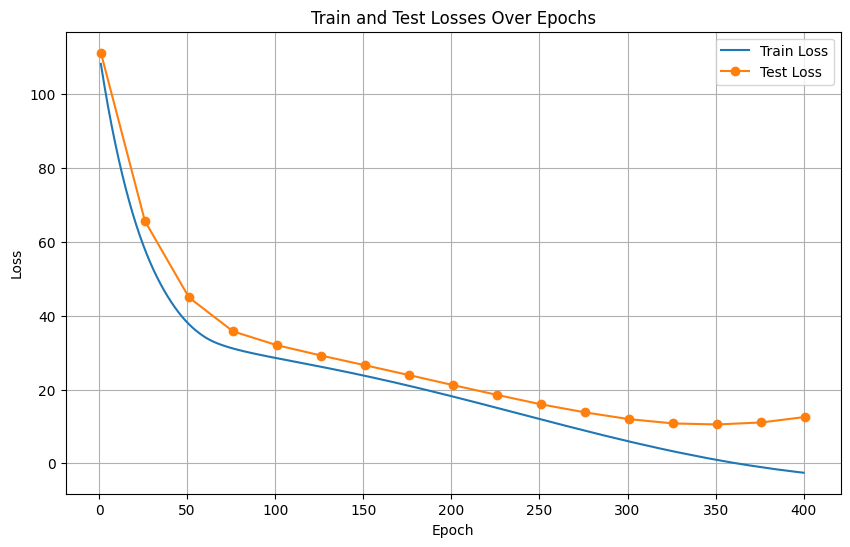

In [ ]:
plot_losses(train_losses_nolag, test_losses_nolag)

#### Approach 3: Incorporating a spatial component
The weather data contains variables for a variety of different locations in Germany. During loading these, I initially averaged them for each hour. But incorporating the spatial data by, e.g. splitting an important variable into regions in Germany (NW, NE, SE, SW) might give the model more of an overview!

##### **Step 1: identify a key weather feature to split**
When looking at the data, several possible candidates can be found:
- cdir (Clear-sky direct solar radiation at surface): Represents the maximum potential solar radiation under clear skies. Useful but doesn't account for clouds.
- tcc (total cloud cover): Directly impacts the amount of solar radiation reaching the ground. High cloud cover means less solar supply.
- sund (sunshine duration): The amount of time the sun is shining. Closely related to cloud cover and solar radiation.
- **ssr (Surface net solar radiation)**: This is the most direct measure of the actual solar energy reaching the surface, taking into account clouds and atmospheric conditions.

Sund is highly relevant but a measure of time, not energy. Tcc is important, as clouds impact the solar radiation and thus power generation a lot. Ssr already captures the net effect of clouds and other atmospheric conditions and is a measure of energy influx. It measures the energy that is actually available at the surface. <br>
<br>
I hypothesize that regional differences in the ssr correlate with regional differences in solar suppply very likely.

##### **Step 2: Prepare data for K-Means Clustering**

In [ ]:
def load_weather_data_with_locations(fpath):
    """ Loads the weather data and keeps data from different locaions,
    unlike load_and_merge_weather_data which averages the data
    over each location for every point in time"""
    df = pd.read_csv(fpath, sep=',', decimal='.')
    df['time'] = pd.to_datetime(df['time'], utc=True)
    df = df.drop(columns=['forecast_origin'])
    return df

spatial_weather_df_train = load_weather_data_with_locations(weather_data_fpaths[0])
# Get unique locations. I sanity checked and the train and test tables have the same locations!
unique_locations = spatial_weather_df_train[['longitude', 'latitude']].drop_duplicates().copy()
# Calculate the mean of ssr for each unique location across all time steps
location_grouped_weather_df = spatial_weather_df_train.groupby(['longitude', 'latitude'])
# Average ssr per location to check whether different locations have a different ssr.
average_ssr_per_location = location_grouped_weather_df['ssr'].mean().reset_index()
print("Shape of average ssr per location", average_ssr_per_location.shape)
print("Average SSR per location is the previous way of handling the data")
average_ssr_per_location.head()
print("Average ssr vary a lot from location to location")

Shape of average ssr per location (80, 3)
Average SSR per location is the previous way of handling the data
Average ssr vary a lot from location to location


##### **Step 3: Apply K-Means Clustering to the locations**

The goal of this step is to find $k=4$ clusters - based on logitude and latitude - that are able group our ssr data from the 80 different geo-points in our data into 4 regions.

In [ ]:
k=4
# Define KMeans model and fit it to the lon/lat points
kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
kmeans.fit(unique_locations)
# Assign cluster IDs to the unique training locations DataFrame
unique_locations['cluster'] = kmeans.predict(unique_locations)
# Show locations with their cluster IDs
print("Locations with purely geographical cluster assignments:")
print(unique_locations.head)

Locations with purely geographical cluster assignments:
<bound method NDFrame.head of     longitude  latitude  cluster
0         5.8      54.2        2
1         5.8      53.2        2
2         5.8      52.2        2
3         5.8      51.2        2
4         5.8      50.2        0
..        ...       ...      ...
75       14.8      51.2        1
76       14.8      50.2        3
77       14.8      49.2        3
78       14.8      48.2        3
79       14.8      47.2        3

[80 rows x 3 columns]>


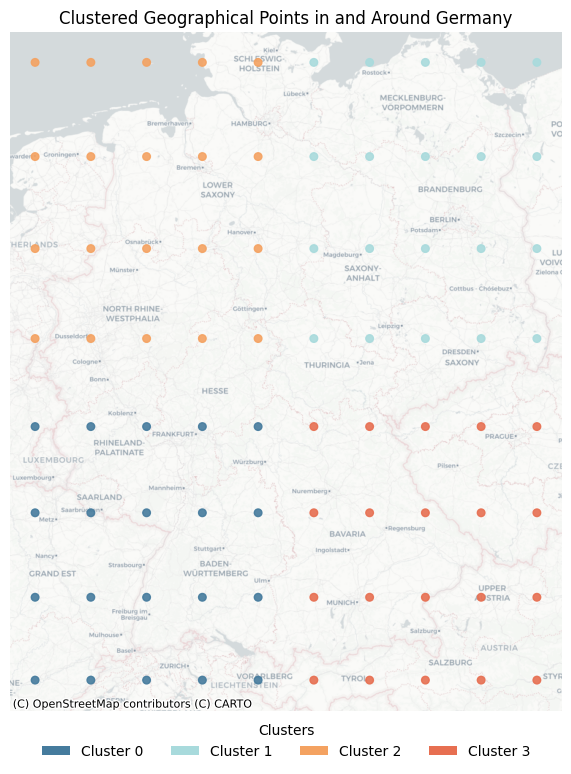

In [ ]:
plot_geographical_clusters(unique_locations)

##### **Step 4: Calculate Regional Features for Each Time Step**
Here, the cluster IDs are mapped to all data points

In [ ]:
spatial_weather_dfs = []
for fpath in weather_data_fpaths:
    df = load_weather_data_with_locations(fpath) # Reuse your loading function
    spatial_weather_dfs.append(df)
# Concat DataFrames and sort by times, long- and latitude
spatial_weather_df = pd.concat(spatial_weather_dfs, ignore_index=True)
spatial_weather_df = spatial_weather_df.sort_values(['time', 'longitude', 'latitude'])
# Predict cluster for all geographical points (train and test data)
spatial_weather_df['cluster'] = kmeans.predict(spatial_weather_df[['longitude', 'latitude']])
spatial_weather_df[['longitude', 'latitude', 'time', 'ssr', 'cluster']].head()

,longitude,latitude,time,ssr,cluster
7,5.8,47.2,2019-01-01 00:00:00+00:00,0.0,0
6,5.8,48.2,2019-01-01 00:00:00+00:00,0.0,0
5,5.8,49.2,2019-01-01 00:00:00+00:00,0.0,0
4,5.8,50.2,2019-01-01 00:00:00+00:00,0.0,0
3,5.8,51.2,2019-01-01 00:00:00+00:00,0.0,2


##### **Step 5: Integrate Regional Features into the full_data**
With the predicted clusters and corresponding ssr values, we can now split our ssr values into four ssr values per time step.

Calculate the average of 'ssr' for each cluster at each time step

In [ ]:
grouped_by_time_and_cluster = spatial_weather_df.groupby(['time', 'cluster'])
# Calculate the mean of 'ssr' for each group
regional_ssr_features = grouped_by_time_and_cluster['ssr'].mean().unstack(level='cluster')
# Rename columns for clarity
regional_ssr_features.columns = [f'ssr_cluster_{int(col)}' for col in regional_ssr_features.columns]
regional_ssr_features.iloc[10:20].head()

,ssr_cluster_0,ssr_cluster_1,ssr_cluster_2,ssr_cluster_3
time,,,,
2019-01-01 10:00:00+00:00,463329.25,235431.20,193574.80,465519.40
2019-01-01 11:00:00+00:00,829697.10,523562.50,454728.50,859105.80
2019-01-01 12:00:00+00:00,1217460.55,834612.15,741497.50,1266154.45
2019-01-01 13:00:00+00:00,1539381.35,1141173.85,1042183.00,1594619.65
2019-01-01 14:00:00+00:00,1756327.85,1325132.50,1228973.05,1798771.70


Create Train and Test data with the ssr cluster columns

In [ ]:
assert regional_ssr_features.index.equals(full_data.index)
# Create data without the averaged ssr column and the regional ssrs
full_data_cluster = full_data.drop(columns=['ssr'])
for cluster_col in regional_ssr_features.columns:
    full_data_cluster[cluster_col] = regional_ssr_features[cluster_col]
full_data_cluster.head()

,solar_supply,cdir,z,msl,blh,tcc,u10,v10,t2m,tsr,...,v100,Installed_Capacity,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,ssr_cluster_0,ssr_cluster_1,ssr_cluster_2,ssr_cluster_3
2019-01-01 00:00:00+00:00,0.0,0.0,3360.296561,103009.967750,507.635043,0.966562,3.867164,1.065368,278.216013,0.0,...,1.122055,44036.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,0.0,0.0
2019-01-01 01:00:00+00:00,0.0,0.0,3360.296561,102964.489612,544.627164,0.959348,4.092345,1.116217,278.310794,0.0,...,1.241379,44036.424429,0.258819,0.965926,0.0,1.0,0.0,0.0,0.0,0.0
2019-01-01 02:00:00+00:00,0.0,0.0,3360.296561,102908.208325,575.103757,0.966846,4.320050,1.223478,278.206292,0.0,...,1.428783,44036.848858,0.500000,0.866025,0.0,1.0,0.0,0.0,0.0,0.0
2019-01-01 03:00:00+00:00,0.0,0.0,3360.296561,102827.034387,612.314609,0.979125,4.638074,1.222571,278.140331,0.0,...,1.501984,44037.273288,0.707107,0.707107,0.0,1.0,0.0,0.0,0.0,0.0
2019-01-01 04:00:00+00:00,0.0,0.0,3360.296561,102725.913987,660.112603,0.981526,4.980449,1.055763,278.102989,0.0,...,1.289936,44037.697717,0.866025,0.500000,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
y_index_cluster = create_forecast_df(full_data_cluster, horizon).index
full_data_std_cluster, X_train_cluster, X_test_cluster, feature_scaler_cluster, train_mask_cluster, y_index_cluster = create_standardized_data(full_data_cluster, feature_cols_static, target_col, train_idx, y_index_cluster, target_scaler)

# Create ground truth data y and map it to tensors
y_df_cluster = create_forecast_df(full_data_std_cluster, horizon)
y_train_cluster, y_test_cluster = y_df_cluster.loc[train_mask_cluster], y_df_cluster.loc[~train_mask_cluster]
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = map(lambda x: df_to_tensor(x, "cpu"), (X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster))

# Extract train and test dates for plotting purposes
dates_train_cluster = full_data_std_cluster.loc[y_index_cluster].loc[train_mask_cluster].index
dates_test_cluster = full_data_std_cluster.loc[y_index_cluster].loc[~train_mask_cluster].index

save_data(X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster, dates_train_cluster, dates_test_cluster, os.path.join(data_folder, "data_cluster.pt"))

print(X_train_cluster.shape, X_test_cluster.shape, y_train_cluster.shape, y_test_cluster.shape)
full_data_std_cluster.head()

Datasets saved successfully
torch.Size([26280, 28]) torch.Size([8736, 28]) torch.Size([26280, 24]) torch.Size([8736, 24])


,solar_supply,cdir,z,msl,blh,tcc,u10,v10,t2m,tsr,...,day_of_year_sin,day_of_year_cos,ssr_cluster_0,ssr_cluster_1,ssr_cluster_2,ssr_cluster_3,solar_supply_t-6,solar_supply_t-12,solar_supply_t-18,solar_supply_t-24
2019-01-02 00:00:00+00:00,-0.653639,-0.901071,9.094947e-13,0.900634,1.615182,0.060135,1.837466,-2.460230,-1.025674,-0.901972,...,0.017213,0.999852,-0.845105,-0.834229,-0.811952,-0.877336,-0.653639,-0.368019,-0.653639,-0.653639
2019-01-02 01:00:00+00:00,-0.653639,-0.901071,9.094947e-13,0.934180,1.727770,-0.214316,1.727689,-2.642626,-1.032728,-0.901972,...,0.017213,0.999852,-0.845105,-0.834229,-0.811952,-0.877336,-0.653639,-0.396846,-0.653639,-0.653639
2019-01-02 02:00:00+00:00,-0.653639,-0.901071,9.094947e-13,0.999948,1.717112,-0.262669,1.610993,-2.801550,-1.055196,-0.901972,...,0.017213,0.999852,-0.845105,-0.834229,-0.811952,-0.877336,-0.653639,-0.487617,-0.642857,-0.653639
2019-01-02 03:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.040758,1.754450,-0.328661,1.543875,-2.953307,-1.081040,-0.901972,...,0.017213,0.999852,-0.845105,-0.834229,-0.811952,-0.877336,-0.653639,-0.596688,-0.579059,-0.653639
2019-01-02 04:00:00+00:00,-0.653639,-0.901071,9.094947e-13,1.083646,1.817195,-0.390214,1.381965,-3.048589,-1.109085,-0.901972,...,0.017213,0.999852,-0.845105,-0.834229,-0.811952,-0.877336,-0.653639,-0.650856,-0.478466,-0.653639


In [ ]:
# Move data to GPU (if available)
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = X_train_cluster.to(device), X_test_cluster.to(device), y_train_cluster.to(device), y_test_cluster.to(device)
# Train model
perm = torch.randperm(X_train_cluster.size(0))
inducing_points = X_train_cluster[perm[:num_inducing]].clone()
model_cluster, likelihood_cluster = create_model(best_config, inducing_points=inducing_points, input_size=X_train_cluster.shape[1], device=device)
model_cluster, likelihood_cluster, train_losses_cluster, test_losses_cluster = train_model(model_cluster, likelihood_cluster, best_config, data=(X_train_cluster, y_train_cluster, X_test_cluster, y_test_cluster), device=device, test_interval=25)
# Move back to CPU to free up space on the GPU
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = X_train_cluster.to(device_cpu), X_test_cluster.to(device_cpu), y_train_cluster.to(device_cpu), y_test_cluster.to(device_cpu)
# Save results
save_training_results(model_cluster, likelihood_cluster, train_losses_cluster, test_losses_cluster, name_addition='_cluster')

Training Model:   0%|          | 0/400 [00:00<?, ?it/s]

Saved model and likelihood successfully.


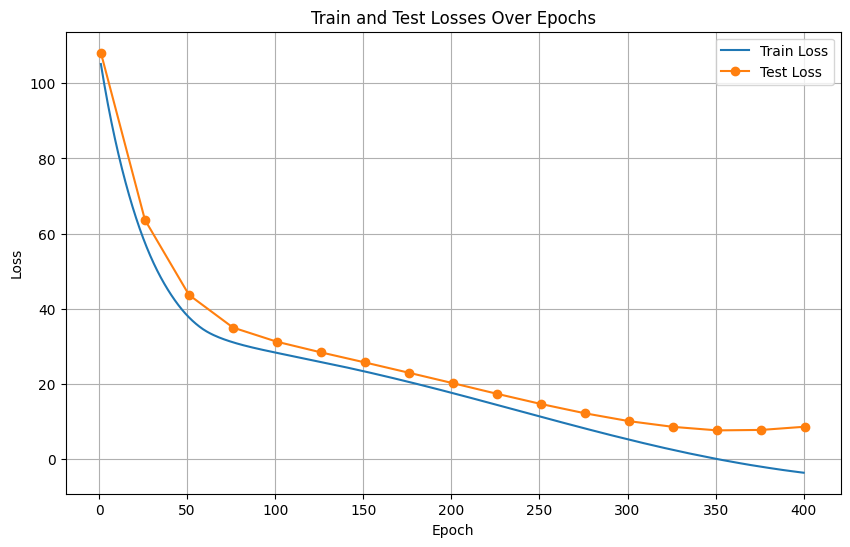

In [ ]:
plot_losses(train_losses_cluster, test_losses_cluster)

## Comparing models

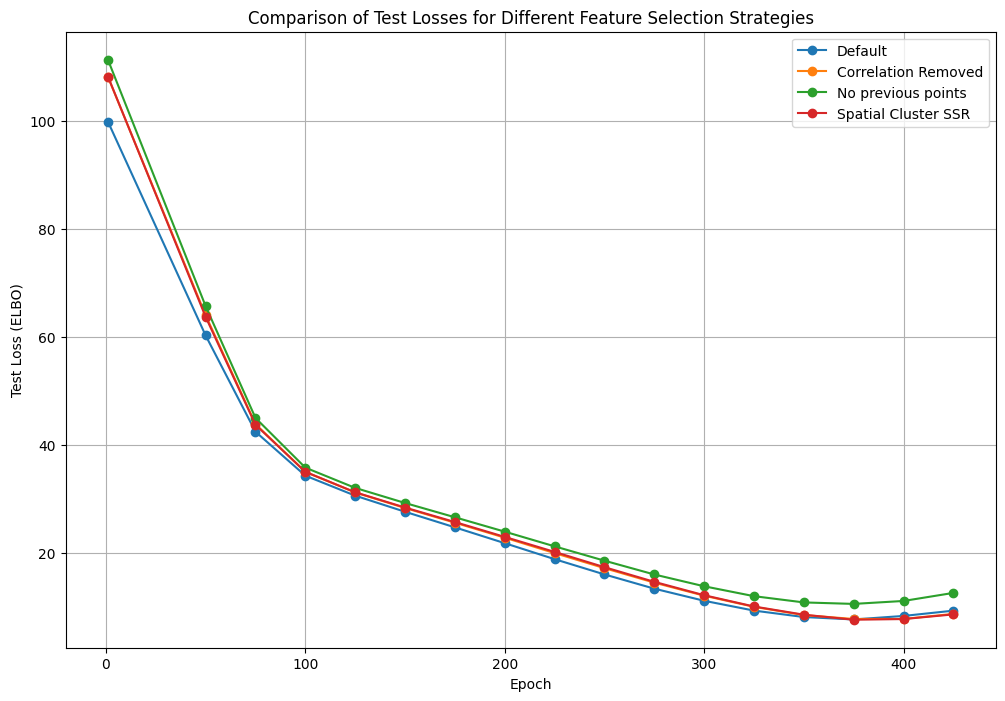

In [ ]:
# test_losses = load_file(os.path.join(model_folder, 'test_losses.pkl'))
# test_losses_corr = load_file(os.path.join(model_folder, 'test_losses_corr.pkl'))
# test_losses_nolag = load_file(os.path.join(model_folder, 'test_losses_nolag.pkl'))
# test_losses_cluster = load_file(os.path.join(model_folder, 'test_losses_cluster.pkl'))

test_losses_comparison = {
    'Default': test_losses,
    'Correlation Removed': test_losses_corr,
    'No previous points': test_losses_nolag,
    'Spatial Cluster SSR': test_losses_cluster,
}

def plot_comparison_losses(test_losses_dict, test_interval=25):
    """
    Plots the test losses of different feature selection strategies over epochs.

    Args:
        test_losses_dict (dict): A dictionary where keys are the names of the
                                  strategies and values are lists of test losses
                                  for each strategy.
        test_interval (int): The interval at which test losses were recorded.
    """
    plt.figure(figsize=(12, 8))
    for strategy_name, losses in test_losses_dict.items():
        if losses:
            test_epochs = [i * test_interval + (test_interval if i > 0 else 1) for i in range(len(losses))]
            plt.plot(test_epochs, losses, marker='o', linestyle='-', label=strategy_name)

    plt.xlabel('Epoch')
    plt.ylabel('Test Loss (ELBO)')
    plt.title('Comparison of Test Losses for Different Feature Selection Strategies')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_comparison_losses(test_losses_comparison)

Look at the last test losses (ELBO)

In [ ]:
print(f"Default approach: {test_losses[-1]:.3f}")
print(f"Correlation Removed approach: {test_losses_corr[-1]:.3f}")
print(f"No previous points approach: {test_losses_nolag[-1]:.3f}")
print(f"Spatial Cluster SSR approach: {test_losses_cluster[-1]:.3f}")

Default approach: 9.287
Correlation Removed approach: 8.685
No previous points approach: 12.574
Spatial Cluster SSR approach: 8.595


This leads to the conclusion that <br>
(a) removing previous time poitns decreases the prediction accuracy by a lot <br>
(b) removing correlated columns makes it easier for the model to focus on important information <br>
(c) Having more fine-grained weather variables improves predictions too

# Benchmarking
Checking how well the model performs

Load the previously selected best model and predict all necessary values

In [ ]:
data = torch.load(os.path.join(data_folder, "data_cluster.pt"), weights_only=False)
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster, dates_train, dates_test = data
with open(os.path.join(data_folder, "target_scaler.pkl"), 'rb') as f:
    target_scaler = pickle.load(f)

model_fname = os.path.join(model_folder, "gp_model_state_dict_cluster.pth")
likelihood_fname = os.path.join(model_folder, "multitask_likelihood_state_dict_cluster.pth")

with open("best_config.pkl", "rb") as f:
    best_config = pickle.load(f)

model, likelihood = load_model(best_config, model_fname, likelihood_fname, X_train_cluster, input_size=X_train_cluster.shape[1], device=device)

Predict all values needed for plotting and further evaluation

In [ ]:
# 1) Move everything to CPU & eval mode
model = model_cluster.to(device_cpu).eval()
likelihood = likelihood_cluster.to(device_cpu).eval()

X_train, y_train = X_train_cluster.to(device_cpu), y_train_cluster.to(device_cpu)
X_test, y_test = X_test_cluster.to(device_cpu), y_test_cluster.to(device_cpu)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Predict with model
    f_preds_train, f_preds_test = model(X_train), model(X_test)
    # Predict likelihood
    y_preds_train, y_preds_test = likelihood(f_preds_train), likelihood(f_preds_test)
    # Get confidence regions for likelihood predictions
    lower_conf_train, upper_conf_train = y_preds_train.confidence_region()
    lower_conf_test, upper_conf_test = y_preds_test.confidence_region()

    # Scale everything back to the original scale (Inverse scale)
    # Target data (Solar power generation)
    y_train_unscaled = torch.tensor(target_scaler.inverse_transform(y_train))
    y_test_unscaled = torch.tensor(target_scaler.inverse_transform(y_test))
    # Predicted target data
    y_preds_train_mean_unscaled = torch.tensor(target_scaler.inverse_transform(y_preds_train.mean))
    y_preds_test_mean_unscaled = torch.tensor(target_scaler.inverse_transform(y_preds_test.mean))
    # Confidence intervals
    lower_conf_train_unscaled, upper_conf_train_unscaled = (
        torch.tensor(target_scaler.inverse_transform(lower_conf_train)),
        torch.tensor(target_scaler.inverse_transform(upper_conf_train)))
    lower_conf_test_unscaled, upper_conf_test_unscaled = (
        torch.tensor(target_scaler.inverse_transform(lower_conf_test)),
        torch.tensor(target_scaler.inverse_transform(upper_conf_test)))

## RMSE and CRPS for each forecast horizon

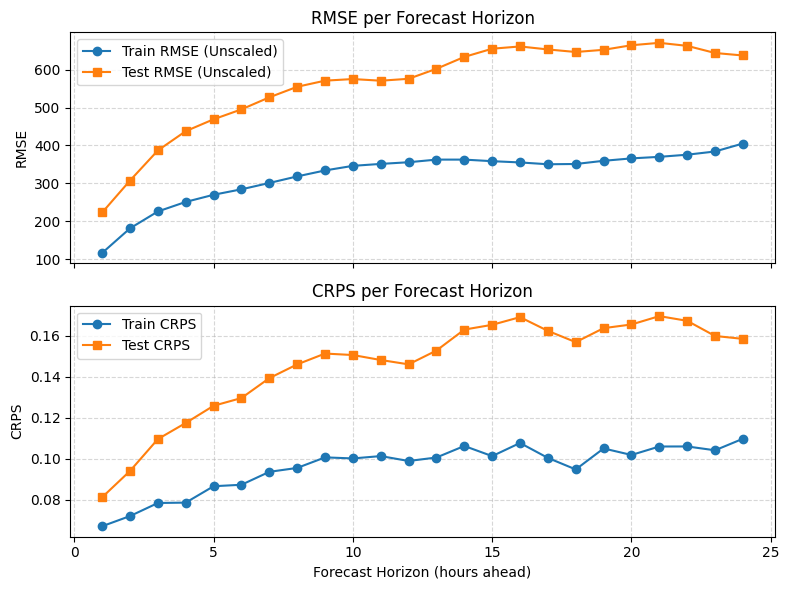

In [ ]:
rmse_per_horizon_train_unscaled = torch.sqrt(((y_preds_train_mean_unscaled - y_train_unscaled) ** 2).mean(dim=0)).numpy()  # (24,)
rmse_per_horizon_test_unscaled = torch.sqrt(((y_preds_test_mean_unscaled - y_test_unscaled) ** 2).mean(dim=0)).numpy()  # (24,)

crps_per_horizon_train = []
crps_per_horizon_test = []

for i in range(horizon):
    # Calculate CRPS for the i-th forecast horizon on the training set
    # y_preds_train is a MultivariateNormal distribution, so we can get mean and variance
    mean_train_i = y_preds_train.mean[:, i].detach().cpu().numpy()
    std_train_i = y_preds_train.stddev[:, i].detach().cpu().numpy()
    y_train_i = y_train[:, i].cpu().numpy()

    # Use crps_gaussian from properscoring
    crps_train_i = ps.crps_gaussian(y_train_i, mu=mean_train_i, sig=std_train_i).mean()
    crps_per_horizon_train.append(crps_train_i)

    # Calculate CRPS for the i-th forecast horizon on the test set
    mean_test_i = y_preds_test.mean[:, i].detach().cpu().numpy()
    std_test_i = y_preds_test.stddev[:, i].detach().cpu().numpy()
    y_test_i = y_test[:, i].detach().cpu().numpy()

    crps_test_i = ps.crps_gaussian(y_test_i, mu=mean_test_i, sig=std_test_i).mean()
    crps_per_horizon_test.append(crps_test_i)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Plot RMSE in the first subplot
axes[0].plot(range(1, horizon + 1), rmse_per_horizon_train_unscaled, label='Train RMSE (Unscaled)', marker='o')
axes[0].plot(range(1, horizon + 1), rmse_per_horizon_test_unscaled, label='Test RMSE (Unscaled)', marker='s')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE per Forecast Horizon')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot CRPS in the second subplot
axes[1].plot(range(1, horizon + 1), crps_per_horizon_train, label='Train CRPS', marker='o')
axes[1].plot(range(1, horizon + 1), crps_per_horizon_test, label='Test CRPS', marker='s')
axes[1].set_xlabel('Forecast Horizon (hours ahead)')
axes[1].set_ylabel('CRPS')
axes[1].set_title('CRPS per Forecast Horizon')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

Generally, predictions get wors, the further our prediction lies into the future, but it seems like predictions get better around the 12, 18 and 24 hour  mark. This is likely because the solar values from 6, 12, 18 and 24 hours ago are included in the input data and the model likely knows that the values are likely to be similar to these.

## Look at the confidence intervals for the dates (predictions are averaged for each day)
This plot shows the average prediction uncertainty over time for the training (blue) and testing (green) data. Higher values indicate higher uncertainty. It is computed by calculating the average confidence width of the 24 hour prediction horizon.



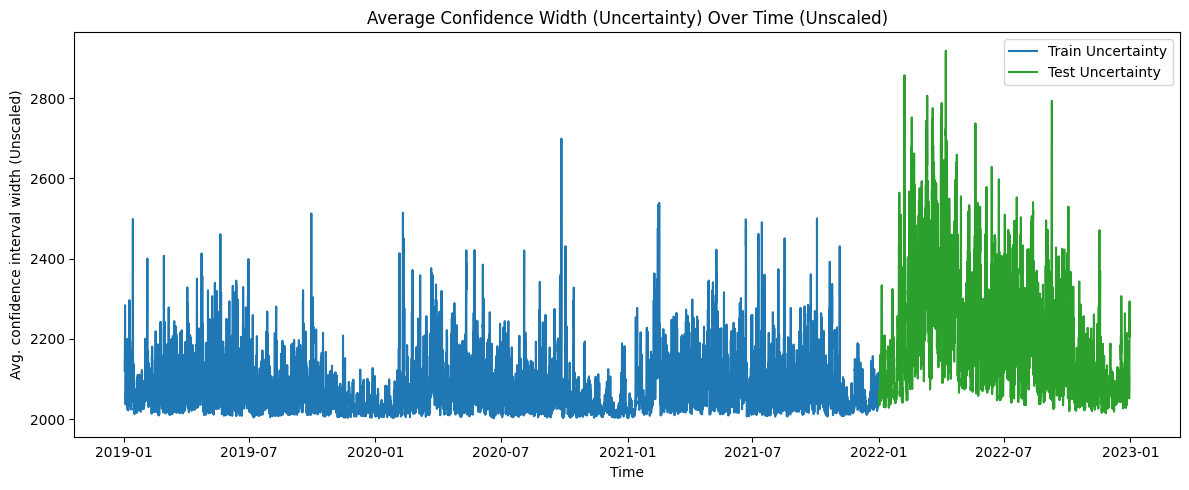

In [ ]:
with torch.no_grad():
    f, ax = plt.subplots(1, 1, figsize=(12, 5))

    # Compute average confidence width for train data (unscaled)
    conf_width_train = (upper_conf_train_unscaled - lower_conf_train_unscaled).mean(dim=1)

    # Compute average confidence width for test data (unscaled)
    conf_width_test = (upper_conf_test_unscaled - lower_conf_test_unscaled).mean(dim=1)

    # Plot for train data in red
    ax.plot(dates_train, conf_width_train.numpy(), '#1f77b4', label='Train Uncertainty')

    # Plot for test data in blue
    ax.plot(dates_test, conf_width_test.numpy(), '#2ca02c', label='Test Uncertainty')

    ax.set_title("Average Confidence Width (Uncertainty) Over Time (Unscaled)")
    ax.set_ylabel("Avg. confidence interval width (Unscaled)")
    ax.set_xlabel("Time")
    ax.legend() # Add legend to distinguish train and test lines
    plt.tight_layout()
    plt.show()

Generally, the model is a lot less certain in its predictions in the test year. <br>
Predictions are generally most certain around January.

## Check the average confidence width per forecast horizon
For each hour in the forecast, we look at the average confidence over the whole data. <br>
This might show us whether the model has trouble predicting solar power generation values that are a lot later than the starting point - or it might only have trouble predicting values in the middle of the forecast horizon, as the values at the start and end are closely related to each other.

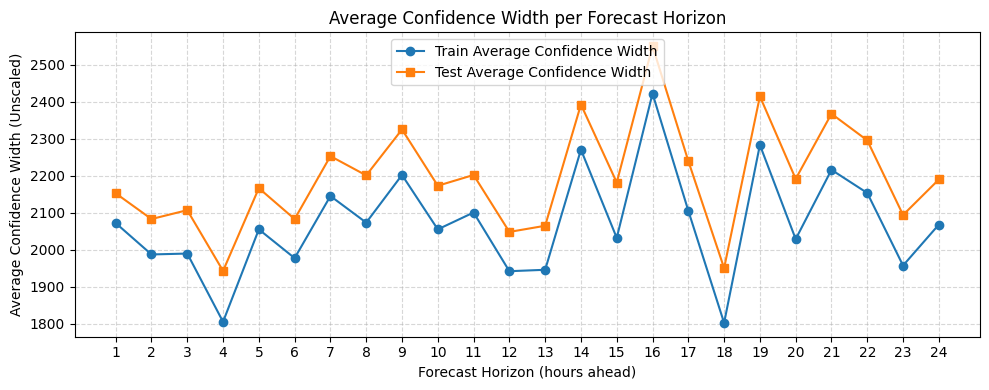

In [ ]:
with torch.no_grad():
    # Calculate the confidence width for each time point and each horizon
    conf_width_train = upper_conf_train_unscaled - lower_conf_train_unscaled  # Shape: (N_train, 24)
    conf_width_test = upper_conf_test_unscaled - lower_conf_test_unscaled    # Shape: (N_test, 24)

    # Calculate the average confidence width across all time points for each horizon
    avg_conf_width_by_horizon_train = conf_width_train.mean(dim=0).numpy() # Shape: (24,)
    avg_conf_width_by_horizon_test = conf_width_test.mean(dim=0).numpy()   # Shape: (24,)

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, horizon + 1), avg_conf_width_by_horizon_train, marker='o', label='Train Average Confidence Width')
    plt.plot(range(1, horizon + 1), avg_conf_width_by_horizon_test, marker='s', label='Test Average Confidence Width')

    plt.xlabel('Forecast Horizon (hours ahead)')
    plt.ylabel('Average Confidence Width (Unscaled)')
    plt.title('Average Confidence Width per Forecast Horizon')
    plt.xticks(range(1, horizon + 1)) # Set x-ticks for each horizon
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper center')
    plt.tight_layout()
    plt.show()

Interestingly enough, this is a little bit contrary to the plots that showed the errors per forecast horizon. The model remains as confident at the end of the forecast horizon as it is at the beginning. <br>
The model is most confident when predicting values that lie 4 and 18 hours into the future.
<br>
So the errors that the model produces don't necessarily correlate with its confidence. This could suggest that the models' uncertainty estimates are not well-calibrated or that the data patterns at certain hours are easier to predict, regardless of temporal distance
<br>
<br>
The confidence in test predictions is generally ~10% worse than when using train data.

## Check if seasonality makes a difference


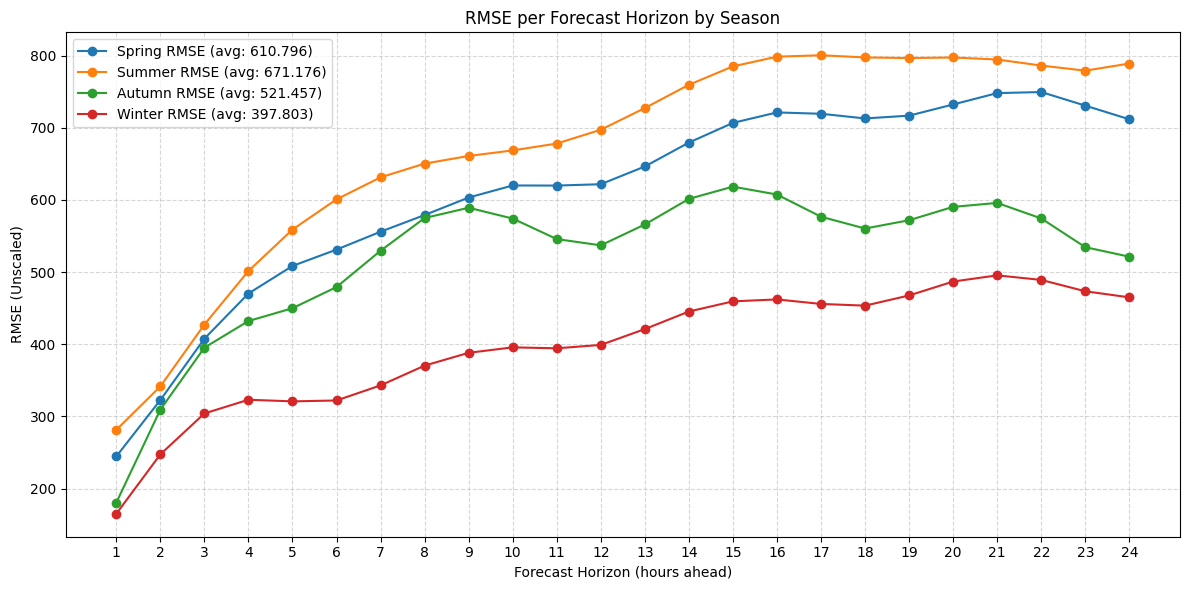

In [ ]:
def get_season(date):
    month = date.month
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

# Add season to the test dates
test_dates_df = pd.DataFrame(dates_test, columns=['time'])
test_dates_df['season'] = test_dates_df['time'].apply(get_season)

# Convert tensors back to numpy for easier handling
y_test_np = y_test_unscaled.numpy()
y_preds_test_np = y_preds_test_mean_unscaled.numpy()

# Calculate RMSE for each season and each horizon
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
rmse_by_season = {}

for season in seasons:
    # Get indices for the current season
    season_indices = test_dates_df[test_dates_df['season'] == season].index.tolist()

    if len(season_indices) > 0:
        # Filter actual and predicted values for the current season
        y_test_season = y_test_np[season_indices, :]
        y_preds_test_season = y_preds_test_np[season_indices, :]

        # Calculate squared errors for the season
        squared_errors_season = (y_preds_test_season - y_test_season) ** 2

        # Calculate mean squared error for each horizon in the season
        mse_per_horizon_season = squared_errors_season.mean(axis=0)

        # Calculate RMSE for each horizon in the season
        rmse_per_horizon_season = np.sqrt(mse_per_horizon_season)

        rmse_by_season[season] = rmse_per_horizon_season

# Plotting the seasonal comparison
plt.figure(figsize=(12, 6))
for season, rmse_values in rmse_by_season.items():
    if len(rmse_values) == horizon:
        plt.plot(range(1, horizon + 1), rmse_values, marker='o', label=f'{season} RMSE (avg: {np.mean(rmse_values):.3f})')
    else:
        print(f"Warning: Skipping season '{season}' due to incomplete horizon data.")


plt.xlabel('Forecast Horizon (hours ahead)')
plt.ylabel('RMSE (Unscaled)')
plt.title('RMSE per Forecast Horizon by Season')
plt.xticks(range(1, horizon + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Winter is by far the easiest to predict for the network, whereas summer seems to be the hardest to predict correctly.
<br>
A possible explanation for this is that the overall solar power peaks are more moderate and predictable during the winter (as for instance cloud cover is generally higher). During summer, there are extreme peaks for some days, sometimes around 12:00, sometimes around 14:00. So the position of the peak as well as the height is harder to predict, as solar power values tend to be the highest in summer.

## Plot the mean & average confidence for each day's prediction (mean over 24 values)

By comparing the predictions & confidence intervals of train & test data, we can check whether performance degrades strongly on the test set, hinting to overfitting the train data.

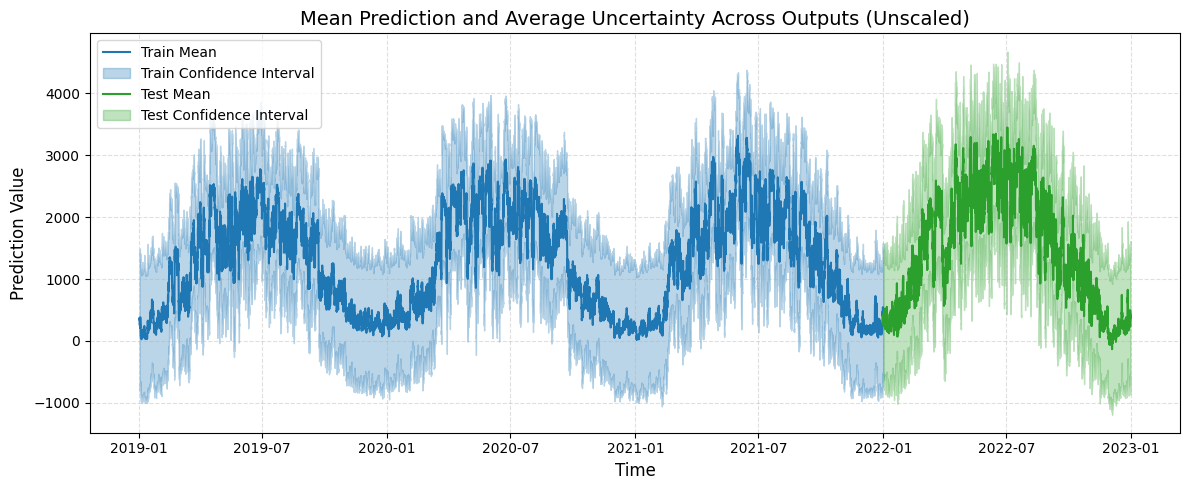

In [ ]:
with torch.no_grad():
    f, ax = plt.subplots(1, 1, figsize=(12, 5))

    mean_mean_train_unscaled = y_preds_train_mean_unscaled.mean(dim=1)
    lower_mean_train_unscaled = lower_conf_train_unscaled.mean(dim=1)
    upper_mean_train_unscaled = upper_conf_train_unscaled.mean(dim=1)

    ax.plot(dates_train, mean_mean_train_unscaled.numpy(), color='#1f77b4', label='Train Mean')
    ax.fill_between(dates_train,
                    lower_mean_train_unscaled.numpy(),
                    upper_mean_train_unscaled.numpy(),
                    color='#1f77b4',
                    alpha=0.3,
                    label='Train Confidence Interval')

    mean_mean_test_unscaled = y_preds_test_mean_unscaled.mean(dim=1)
    lower_mean_test_unscaled = lower_conf_test_unscaled.mean(dim=1)
    upper_mean_test_unscaled = upper_conf_test_unscaled.mean(dim=1)

    ax.plot(dates_test, mean_mean_test_unscaled.numpy(), color='#2ca02c', label='Test Mean')
    ax.fill_between(dates_test,
                    lower_mean_test_unscaled.numpy(),
                    upper_mean_test_unscaled.numpy(),
                    color='#2ca02c',
                    alpha=0.3,
                    label='Test Confidence Interval')

    ax.set_title("Mean Prediction and Average Uncertainty Across Outputs (Unscaled)", fontsize=14)
    ax.set_ylabel("Prediction Value", fontsize=12)
    ax.set_xlabel("Time", fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

By plotting the models' predictions, we can see that it has clearly learned the seasonal patterns of our data and generalizes well in that regard to unseen data. During the extreme values, confidence intervals get wider, showing that the model is more uncertain during summer.

## Compare the actual predictions across different forecast horizons

In [ ]:
import matplotlib.lines as mlines

ncols = 4
nrows = math.ceil(horizon / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), sharex=True)
axes = axes.flatten()

# Colors and alpha
train_obs_color = 'gray'
train_pred_color = '#1f77b4'  # blue
train_ci_alpha = 0.15

test_obs_color = 'gray'
test_pred_color = '#2ca02c'   # green
test_ci_alpha = 0.15

with torch.no_grad():
    for i in range(horizon):
        ax = axes[i]

        # Plot Train Data
        ax.plot(dates_train, y_train_unscaled[:, i].numpy(), '.', color=train_obs_color, alpha=0.2)
        ax.plot(dates_train, y_preds_train_mean_unscaled[:, i].numpy(), color=train_pred_color, alpha=0.75)
        ax.fill_between(dates_train,
                        lower_conf_train_unscaled[:, i].numpy(),
                        upper_conf_train_unscaled[:, i].numpy(),
                        color=train_pred_color, alpha=train_ci_alpha)

        # Plot Test Data
        ax.plot(dates_test, y_test_unscaled[:, i].numpy(), 'x', color=test_obs_color, alpha=0.2)
        ax.plot(dates_test, y_preds_test_mean_unscaled[:, i].numpy(), color=test_pred_color, alpha=0.75)
        ax.fill_between(dates_test,
                        lower_conf_test_unscaled[:, i].numpy(),
                        upper_conf_test_unscaled[:, i].numpy(),
                        color=test_pred_color, alpha=test_ci_alpha)

        ax.set_title(f'+{i+1}h Forecast')
        ax.grid(True, linestyle='--', alpha=0.4)

        # Y-label only on left column
        if i % ncols == 0:
            ax.set_ylabel('Solar Supply')

        # X-label and rotation only on bottom row
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel('Time')
            ax.tick_params(axis='x', rotation=80)

    # Remove unused axes
    for j in range(horizon, len(axes)):
        fig.delaxes(axes[j])

# Create legend handles
handles = [
    mlines.Line2D([], [], color=train_pred_color, label='Mean Train Prediction'),
    mpatches.Patch(color=train_pred_color, alpha=train_ci_alpha, label='Train Confidence'),
    mlines.Line2D([], [], marker='o', color=train_obs_color, linestyle='None', alpha=0.2, label='Observed Train Data'),
    mlines.Line2D([], [], color=test_pred_color, label='Mean Test Prediction'),
    mpatches.Patch(color=test_pred_color, alpha=test_ci_alpha, label='Test Confidence'),
    mlines.Line2D([], [], marker='o', color=test_obs_color, linestyle='None', alpha=0.2, label='Observed Test Data'),
]

fig.suptitle('Forecast Horizon Predictions and Confidence Intervals (Train & Test Data)', fontsize=16)
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=6, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

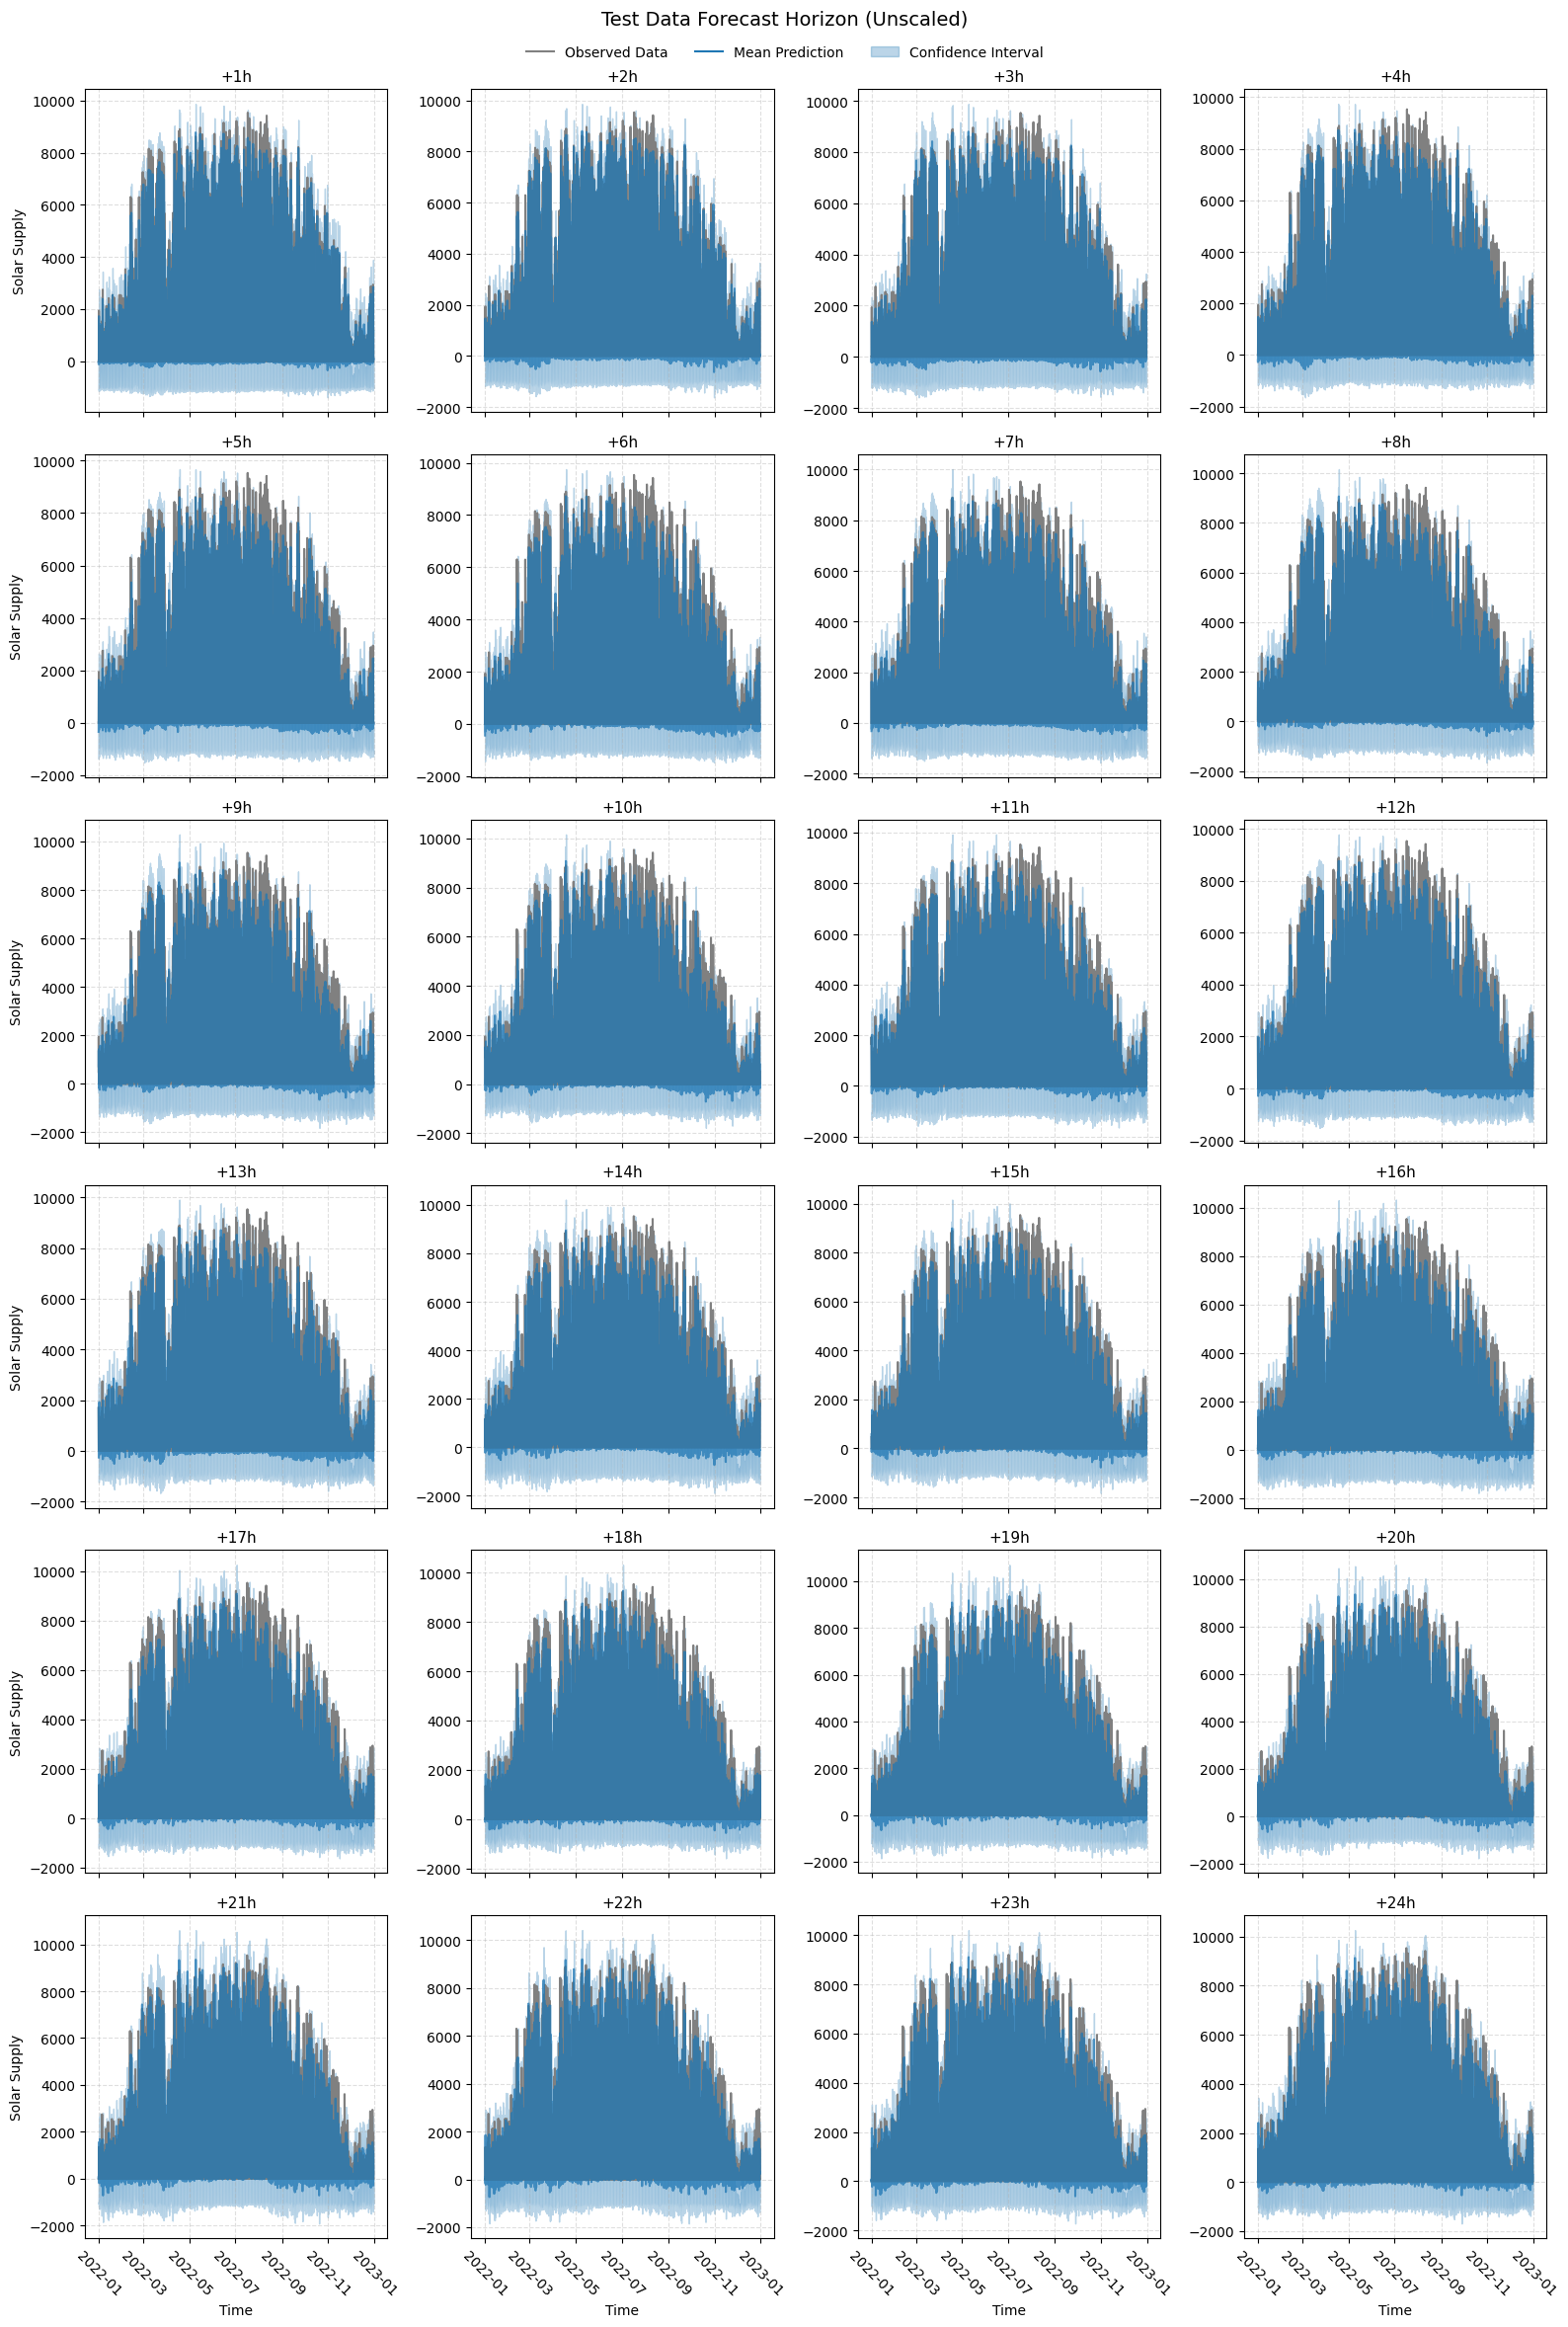

In [ ]:
# Layout configuration
ncols = 4
nrows = math.ceil(horizon / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), sharex=True)
axes = axes.flatten()

# Define styles
obs_color = 'gray'
pred_color = '#1f77b4'
ci_alpha = 0.3

# Proxy legend handles
obs_handle = plt.Line2D([], [], color=obs_color, label='Observed Data')
mean_handle = plt.Line2D([], [], color=pred_color, label='Mean Prediction')
ci_patch = mpatches.Patch(color=pred_color, alpha=ci_alpha, label='Confidence Interval')

with torch.no_grad():
    for i in range(horizon):
        ax = axes[i]

        # Plot observed, prediction, and CI
        ax.plot(dates_test, y_test_unscaled[:, i].numpy(), color=obs_color, alpha=1.0)
        ax.plot(dates_test, y_preds_test_mean_unscaled[:, i].numpy(), color=pred_color, linewidth=1.5, alpha=0.75)
        ax.fill_between(
            dates_test,
            lower_conf_test_unscaled[:, i].numpy(),
            upper_conf_test_unscaled[:, i].numpy(),
            color=pred_color,
            alpha=ci_alpha
        )

        ax.set_title(f'+{i+1}h', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)

        # Label only outer axes to reduce clutter
        if i % ncols == 0:
            ax.set_ylabel('Solar Supply')
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel('Time')
            ax.tick_params(axis='x', rotation=-45)

    # Remove unused axes
    for j in range(horizon, len(axes)):
        fig.delaxes(axes[j])

    # Title and shared legend
    fig.suptitle('Test Data Forecast Horizon (Unscaled)', fontsize=14)
    fig.legend(handles=[obs_handle, mean_handle, ci_patch],
               loc='upper center',
               bbox_to_anchor=(0.5, 0.97),
               ncol=3,
               frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.975])
    plt.show()

For the first half of the year, predictions seem to be quite solid, even with longer forecast horizons. But between July and November, the models' predicted  values worsen.

## Plot a full week of solar energy production from a random starting point

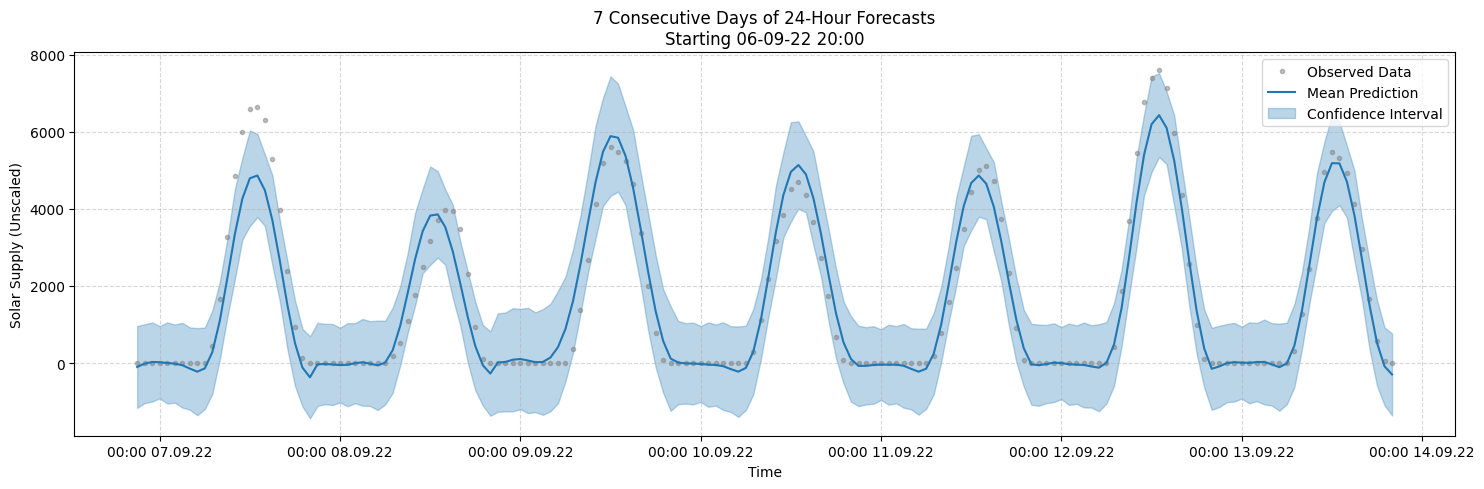

In [ ]:
num_days = 7
total_hours = num_days * horizon

# Pick a valid random start index
max_start_index = len(dates_test) - total_hours
start_idx = np.random.randint(0, max_start_index)

# Create a continuous datetime index covering all 7 days hourly
start_date = dates_test[start_idx]
full_forecast_dates = pd.date_range(start=start_date + pd.Timedelta(hours=1), periods=total_hours, freq='h')

# Gather predictions and true values concatenated over the 7 days
with torch.no_grad():
    # Collect tensors for the 7 horizons
    pred_means = []
    lowers = []
    uppers = []
    trues = []

    for day in range(num_days):
        idx = start_idx + day * horizon
        pred_means.append(y_preds_test_mean_unscaled[idx, :].numpy())
        lowers.append(lower_conf_test_unscaled[idx, :].numpy())
        uppers.append(upper_conf_test_unscaled[idx, :].numpy())
        trues.append(y_test_unscaled[idx, :].numpy())

    pred_means = np.concatenate(pred_means)
    lowers = np.concatenate(lowers)
    uppers = np.concatenate(uppers)
    trues = np.concatenate(trues)

# Plot all in one figure
plt.figure(figsize=(15, 5))

plt.plot(full_forecast_dates, trues, 'o', color='gray', alpha=0.5, markersize=3, label='Observed Data')
plt.plot(full_forecast_dates, pred_means, '-', color='#1f77b4', label='Mean Prediction')
plt.fill_between(full_forecast_dates, lowers, uppers, color='#1f77b4', alpha=0.3, label='Confidence Interval')

plt.title(f'7 Consecutive Days of 24-Hour Forecasts\nStarting {start_date.strftime("%d-%m-%y %H:%M")}')
plt.xlabel('Time')
plt.ylabel('Solar Supply (Unscaled)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M %d.%m.%y'))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

To look at how a consecutive weeek of predictions look like. We always use data from 0:00 as input. The model has learned the overall trend of predicting low values during the night, a Gaussian-like curve each day and a peak sometime around noon. <br>
Here, we can also see some shortcomings:
- It predicts negative values at night (physically impossible, as power generation has to be $\geq 0$)
- Sometimes it's not able to correctly predict the time of highest power generation, i.e. the peak. (E.g. on the 08.09.22)
- Most of the days, the true values are still within the confidence interval.

Since starting predictions consistently at 0:00 is not a realistic use case, I'll generate another plot using random starting times on random days to eliminate this confounding factor.

## Plot predictions for a few days

Select 9 random time points from the test set for plotting the full horizon

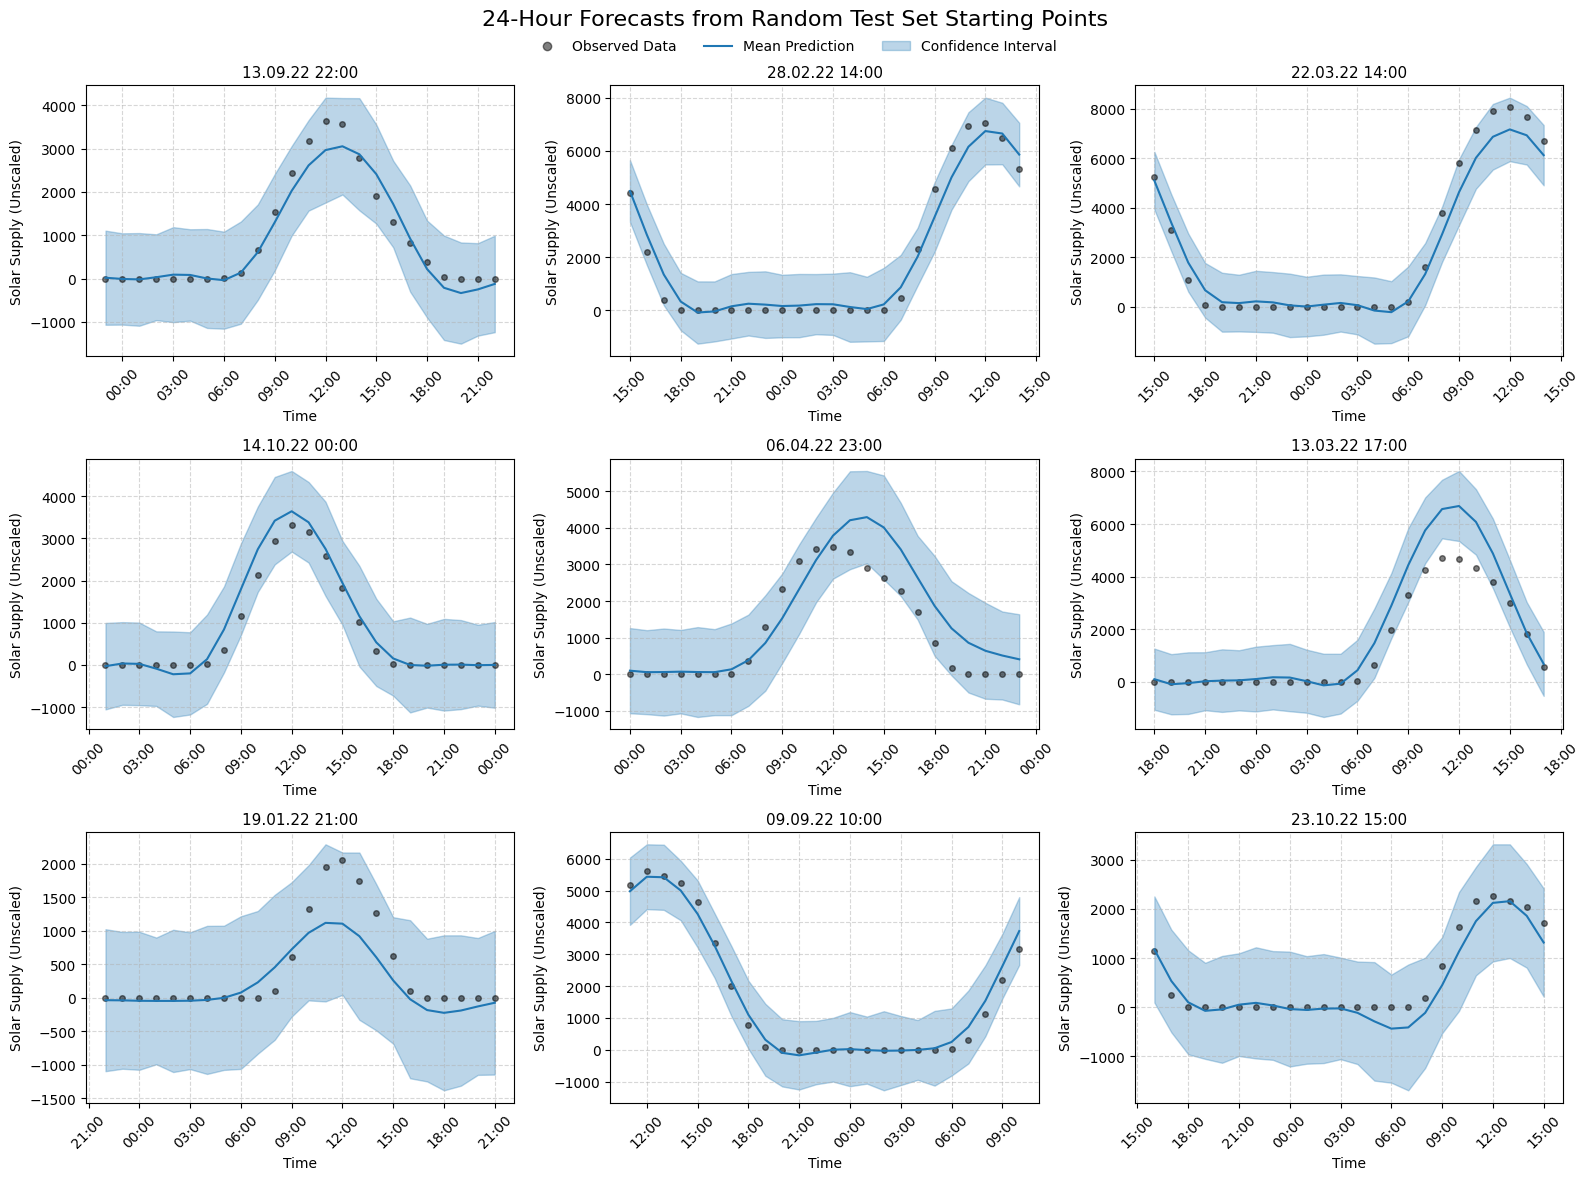

In [ ]:
np.random.seed(RANDOM_SEED)
num_start_points_to_plot = 9

# Select valid random indices from test set (enough room for 24-hour horizon)
max_start_index = len(dates_test) - horizon
selected_start_indices = np.random.choice(max_start_index, num_start_points_to_plot, replace=False)

# Set up grid
ncols = 3
nrows = math.ceil(num_start_points_to_plot / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4), sharex=False)
axes = axes.flatten()

# Create proxy artist for confidence interval
ci_patch = mpatches.Patch(color='#1f77b4', alpha=0.3, label='Confidence Interval')

# Model to device
with torch.no_grad():
    model.eval()
    likelihood.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    likelihood = likelihood.to(device)
    X_test = X_test.to(device)

    for plot_idx, i in enumerate(selected_start_indices):
        ax = axes[plot_idx]
        start_date = dates_test[i]

        # Data slices
        pred_mean = y_preds_test_mean_unscaled[i, :]
        lower = lower_conf_test_unscaled[i, :]
        upper = upper_conf_test_unscaled[i, :]
        true = y_test_unscaled[i, :]

        forecast_dates = pd.date_range(start=start_date + pd.Timedelta(hours=1), periods=horizon, freq='h')

        # Plot true observed values
        if len(forecast_dates) == len(true):
            ax.plot(forecast_dates, true.numpy(), color='black', marker='o', linestyle='None', alpha=0.5, markersize=4, label='Observed Data')

        # Plot predicted mean
        ax.plot(forecast_dates, pred_mean.numpy(), color='#1f77b4', linestyle='-', label='Mean Prediction')

        # Plot confidence interval
        ax.fill_between(forecast_dates,
                        lower.numpy(),
                        upper.numpy(),
                        color='#1f77b4',
                        alpha=0.3)

        # Title
        ax.set_title(start_date.strftime('%d.%m.%y %H:%M'), fontsize=11)

        # Formatting
        ax.set_xlabel('Time')
        ax.set_ylabel('Solar Supply (Unscaled)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    # Remove unused subplots
    for j in range(num_start_points_to_plot, len(axes)):
        fig.delaxes(axes[j])

    # Global title and legend
    fig.suptitle('24-Hour Forecasts from Random Test Set Starting Points', fontsize=16)
    # Create proper handles and labels for legend
    obs_handle = plt.Line2D([], [], color='black', marker='o', linestyle='None', alpha=0.5)
    mean_handle = plt.Line2D([], [], color='#1f77b4', linestyle='-')
    ci_patch = mpatches.Patch(color='#1f77b4', alpha=0.3)

    fig.legend(
        handles=[obs_handle, mean_handle, ci_patch],
        labels=['Observed Data', 'Mean Prediction', 'Confidence Interval'],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.965),
        ncol=3,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.975])
    plt.show()

This plot shows that the model isn't able to perfectly predict the peak solar prediction on each day but almost all the ground truth values are still within the model's confidence intervals, which are notably quite big though (usually ~1000 MW). <br>
For some days, the model correctly predicts the solar power generation, with the correct time of the peak, and its corresponding maximum value quite well!

# Discussion: Is this a good model with the given task & data?
**Strengths:**
- Uncertainty estimates: GPs naturally provide predictive distributions, not just point estimates—important for decision-making in energy systems.
- Captures output dependencies: The Latent Multi-Output (LMC) structure captures correlations between the 24 forecasted hours, improving multi-step consistency.
- Scalable via approximation: Variational inference with inducing points reduces the otherwise cubic cost, making it feasible for datasets with tens of thousands of samples.
- Flexible and interpretable: Non-parametric modeling handles non-linearities without deep architectures, and kernel parameters offer intuitive insights (e.g. lengthscales).
- Less hyperparameter tuning: Compared to deep learning models, GPs often require fewer tweaks to train effectively.

**Weaknesses:**
- Still computationally expensive: Even with approximation, training scales with $\mathcal{O}(NM^2)$, which can be costly with many inducing points $M$.
- Less expressive than deep models: Shallow GPs may underfit in high-dimensional or highly non-linear settings.
- Approximation trade-offs: Variational inference may underestimate uncertainty or oversmooth predictions if the inducing set is too small or poorly chosen.
- No built-in time series structure: GPs don't inherently model temporal sequences; they require manual engineering of lagged or periodic features.
- Kernel sensitivity: Performance depends heavily on kernel choice.

In summary, approximate GPs are a good, uncertainty-aware approach to time-series forecasting. Especially when interpretability and knowledge about confidence are important. But deep models might outperform them in raw accuracy when large data and complex dynamics are involved. <br>
A Transformer-based model will probably be a better suited model than approximate GPs for this task, especially when modeling long-range temporal dependencies and complex seasonality in the solar power time series. Transformers can automatically learn rich temporal features from large datasets. But they typically require more training data, are harder to interpret, and don't natively provide uncertainty estimates—making them more suitable when accuracy is the priority, and uncertainty is less critical.

# Conclusion
Given the limited data and computational resources, the model performs quite well. Possible extensions include incorporating multiple input features with spatial separation, and using a more fine-grained temporal encoding—such as including the season, month, or even the day within the month when each data point was recorded. With these extensions, the model may achieve narrower confidence intervals and higher prediction accuracy, thereby increasing its reliability.